In [ ]:
import os
import pickle
import numpy as np
import pandas as pd
import seaborn as sns
from tqdm.auto import tqdm
from datetime import datetime
import matplotlib.pyplot as plt
sns.set_theme()

import utils_DevTrad

# Base font size for ticks
base_fontsize = 8
# Calculate font sizes for labels and title
label_fontsize = base_fontsize * 1.16
title_fontsize = base_fontsize * 1.16
# Update Matplotlib rcParams
plt.rcParams.update({
    "font.size": 2*base_fontsize,           # Set default font size for text
    "xtick.labelsize": 2*base_fontsize,      # Set font size for x-tick labels
    "ytick.labelsize": 2*base_fontsize,      # Set font size for y-tick labels
    "axes.labelsize": 2*label_fontsize,      # Set font size for x and y labels
    "axes.titlesize": 2*title_fontsize       # Set font size for the title
})

# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

pool_name = 'usdc_weth_005'
main_dir = "/home/user/code_and_output/"
curr_folder = f"{main_dir}{pool_name.upper()}/"
os.chdir(curr_folder)

data_path = "/home/user/data/"
dataset_path = f'{data_path}{pool_name}.pickle'
with open(dataset_path, 'rb') as f:
    df = pickle.load(f)
df.index = pd.to_datetime(df.index)
print('The first observation in the dataset is from', df.index[0])
print('The last observation in the dataset is from', df.index[-1])

df = df[ (df.index >= datetime(2023, 1, 1, 0, 0, 0)) & (df.index < datetime(2025, 1, 1, 0, 0, 0)) ]
df = df.drop_duplicates()

if pool_name+'_sandwich.pickle' in os.listdir():
    with open(pool_name + '_sandwich.pickle', 'rb') as f:
        sandwich_state = pickle.load(f)
    df["sandwich_state"] = sandwich_state

if pool_name+'_jit.pickle' in os.listdir():
    with open(pool_name + '_jit.pickle', 'rb') as f:
        jit_flag = pickle.load(f)
    df["JIT_flag"] = jit_flag

if pool_name+'_ticktime.pickle' in os.listdir():
    with open(pool_name + '_ticktime.pickle', 'rb') as f:
        tick_time_flag = pickle.load(f)
    df["tick_time"] = tick_time_flag

df_swap = df[ (df.Event=='Swap_X2Y') | (df.Event=='Swap_Y2X') ]
df_swap = df_swap.drop_duplicates()
df_mint = df[ df.Event=='Mint' ]
df_mint = df_mint.drop_duplicates()
df_burn_mint = df[ (df.Event=='Burn') | (df.Event=='Mint') ]
df_burn_mint = df_burn_mint.drop_duplicates()
df_burn = df[ df.Event=='Burn' ]
df_burn = df_burn.drop_duplicates()


# MEV finder

Just-in-Time liquidity

In [2]:

if pool_name + '_jit.pickle' not in os.listdir():
    jit_flag = utils_DevTrad.find_jit(df, verbose=False)
    with open(pool_name + '_jit.pickle', 'wb') as f:
        pickle.dump(jit_flag, f)

    df["JIT_flag"] = jit_flag
    df_swap = df[ (df.Event=='Swap_X2Y') | (df.Event=='Swap_Y2X') ]
    df_swap = df_swap.drop_duplicates()
    df_mint = df[ df.Event=='Mint' ]
    df_mint = df_mint.drop_duplicates()
    df_burn_mint = df[ (df.Event=='Burn') | (df.Event=='Mint') ]
    df_burn_mint = df_burn_mint.drop_duplicates()
    df_burn = df[ df.Event=='Burn' ]
    df_burn = df_burn.drop_duplicates()

# Print summary
print(f"Mint: {len(df[ df.Event=='Mint' ])} rows")
print(f"Mint Clean: {len(df[ (df.Event=='Mint') & (df.JIT_flag==0)])} rows")
print(f"Mint JIT: {len(df[ (df.Event=='Mint') & (df.JIT_flag==1)])} rows")


Mint: 75449 rows
Mint Clean: 40738 rows
Mint JIT: 34711 rows


Sandwich

In [3]:

if pool_name + '_sandwich.pickle' not in os.listdir():
    sandwich_state = np.array(utils_DevTrad.find_sandwich(
        df.block_number, df.wallet, df.Event, verbose=True))
    with open(pool_name + '_sandwich.pickle', 'wb') as f:
        pickle.dump(sandwich_state, f)
    
    df["sandwich_state"] = sandwich_state
    df_swap = df[ (df.Event=='Swap_X2Y') | (df.Event=='Swap_Y2X') ]
    df_swap = df_swap.drop_duplicates()
    df_mint = df[ df.Event=='Mint' ]
    df_mint = df_mint.drop_duplicates()
    df_burn_mint = df[ (df.Event=='Burn') | (df.Event=='Mint') ]
    df_burn_mint = df_burn_mint.drop_duplicates()
    df_burn = df[ df.Event=='Burn' ]
    df_burn = df_burn.drop_duplicates()

print('True sandwiches:', (df.sandwich_state == 'Front').sum())
print('Generalized sandwiches:', (df.sandwich_state == 'Front_Mix').sum())
print('Self sandwiches:', (df.sandwich_state == 'Front_Self').sum())
print('Tot sandwiches:', (df.sandwich_state == 'Front').sum() +\
      (df.sandwich_state == 'Front_Mix').sum() +\
        (df.sandwich_state == 'Front_Self').sum())


True sandwiches: 3841
Generalized sandwiches: 2911
Self sandwiches: 261
Tot sandwiches: 7013


Echo swaps

In [4]:

e_swaps = np.array(utils_DevTrad.find_echo(
    df_swap.block_number, df_swap.wallet, df_swap.Event, df_swap.tx_hash))

print(
    'There are',
    len(e_swaps[
        (e_swaps == 'Echo_Start') | (e_swaps == 'Echo_Start_1_Tx')
    ]), 'Echo swaps in the dataset.')
print(
    'Among them',
    len(e_swaps[e_swaps == 'Echo_Start_1_Tx']),
    'occur in the same transaction.')
print()

print('{:<20}{:<20}{:<20}'.format('', 'Mean', 'Std'))
print('{:<20}{:<20}{:<20}'.format(
    'Buy/Sell',
    np.round(np.abs(df_swap[~(e_swaps=="Not")].amount0.values).mean(), 3),
    np.round(np.abs(df_swap[~(e_swaps=="Not")].amount0.values).std(), 3)))
print('{:<20}{:<20}{:<20}'.format(
    'Same Transaction',
    np.round(np.abs(df_swap[
        (e_swaps=="Echo_Start_1_Tx") | (e_swaps=="Echo_1_Tx") | (
            e_swaps=="Echo_End_1_Tx") ].amount0.values).mean(), 3),
    np.round(np.abs(df_swap[
        (e_swaps=="Echo_Start_1_Tx") | (e_swaps=="Echo_1_Tx") | (
            e_swaps=="Echo_End_1_Tx") ].amount0.values).std(), 3)))
print('{:<20}{:<20}{:<20}'.format(
    'Different',
    np.round(np.abs(df_swap[
        (e_swaps=="Echo_Start") | (e_swaps=="Echo") | (
            e_swaps=="Echo_End") ].amount0.values).mean(), 3),
    np.round(np.abs(df_swap[
        (e_swaps=="Echo_Start") | (e_swaps=="Echo") | (
            e_swaps=="Echo_End") ].amount0.values).std(), 3)))
print('{:<20}{:<20}{:<20}'.format(
    'Buy/Sell',
    np.round(np.abs(df_swap[e_swaps=="Not"].amount0.values).mean(), 3),
    np.round(np.abs(df_swap[e_swaps=="Not"].amount0.values).std(), 3)))


There are 10993 Echo swaps in the dataset.
Among them 7812 occur in the same transaction.

                    Mean                Std                 
Buy/Sell            31743.727           204098.643          
Same Transaction    20123.78            110374.998          
Different           60183.105           335637.518          
Buy/Sell            48526.24            173334.727          


# Basic Statistics

Compute the active tick-time

In [5]:

if pool_name + '_ticktime.pickle' not in os.listdir():
    # Compute the active liquidity before the analysis period
    with open(dataset_path, 'rb') as f:
        df_temp = pickle.load(f)
    df_temp.index = pd.to_datetime(df_temp.index)
    df_temp = df_temp.drop_duplicates()
    df_temp = df_temp[df_temp.index < datetime(2023, 1, 1, 0, 0, 0)]
    tick_time_flag = utils_DevTrad.liq_change(
        df_temp[df_temp.index < datetime(2023, 1, 1, 0, 0, 0)],
        df
    )
    with open(pool_name + '_ticktime.pickle', 'wb') as f:
        pickle.dump(tick_time_flag, f)
    
    df["tick_time"] = tick_time_flag
    df_swap = df[ (df.Event=='Swap_X2Y') | (df.Event=='Swap_Y2X') ]
    df_swap = df_swap.drop_duplicates()
    


Summarize the main statistics

In [7]:
def tablerow(data, to_print):
    to_print += ' & ' + str(len(data))
    to_print += ' & ' + str(round(100*(data!=0).sum()/len(data), 2))
    data = data[data!=0]
    Q1 = np.quantile(data, 0.25)
    Q3 = np.quantile(data, 0.75)
    SIQ = 1.5 * (Q3-Q1)
    to_print += ' & ' + str(round(100*((data<Q1-SIQ) | (data>Q3+SIQ)).sum()/len(data), 2))
    to_print += ' & ' + str(round(10000*np.min(data), 1))
    to_print += ' & ' + str(round(10000*Q1, 3))
    to_print += ' & ' + str(round(10000*np.median(data), 4))
    to_print += ' & ' + str(round(10000*np.mean(data), 4))
    to_print += ' & ' + str(round(10000*Q3, 3))
    to_print += ' & ' + str(round(10000*np.max(data), 1)) + ' \\\\'
    print(to_print)

x_train = np.log(df_swap.price.values)
x_train = x_train[1:] - x_train[:-1]
tablerow(x_train, '\\textbf{Swap time}')

x_train = np.log(df_swap.price.values)
x_train = x_train[ df_swap.tick_time!=0 ]
x_train = x_train[1:] - x_train[:-1]
tablerow(x_train, '\\textbf{Tick time}')

x_train = np.log(df_swap.price.resample('30s').last())
x_train = x_train.ffill().values
x_train = x_train[1:] - x_train[:-1]
tablerow(x_train, '\\textbf{30 s}')

for n_min in (1, 3, 5, 10, 15):
    x_train = np.log(df_swap.price.resample(f'{n_min}min').last())
    x_train = x_train.ffill().values
    x_train = x_train[1:] - x_train[:-1]
    tablerow(x_train, '\\textbf{'+str(n_min)+' min}')

print('\n')
from scipy.stats import norm
Q3 = norm.sf(0.25)
print(
    'Percentage outliers for a standard normal distribution',
    round(100*(1 - norm.cdf(4*Q3)) + norm.cdf(-4*Q3), 2))

\textbf{Swap time} & 4115697 & 99.99 & 32.99 & -911.8 & -0.097 & -0.0013 & 0.0025 & 0.076 & 925.0 \\
\textbf{Tick time} & 370610 & 100.0 & 4.4 & -911.8 & -7.941 & 0.0759 & 0.0277 & 8.132 & 922.5 \\
\textbf{30 s} & 2105276 & 78.86 & 35.77 & -833.9 & -0.343 & -0.0013 & 0.0062 & 0.316 & 849.7 \\
\textbf{1 min} & 1052638 & 94.31 & 27.92 & -826.4 & -0.881 & -0.0015 & 0.0103 & 0.945 & 446.4 \\
\textbf{3 min} & 350879 & 99.85 & 13.37 & -1137.9 & -3.412 & -0.0012 & 0.0293 & 3.622 & 408.5 \\
\textbf{5 min} & 210527 & 99.98 & 11.04 & -833.8 & -5.206 & 0.0039 & 0.0487 & 5.453 & 424.7 \\
\textbf{10 min} & 105263 & 99.99 & 9.14 & -803.2 & -8.38 & 0.0407 & 0.0974 & 8.731 & 593.0 \\
\textbf{15 min} & 70175 & 99.99 & 8.27 & -1621.9 & -10.745 & 0.1093 & 0.1462 & 11.369 & 584.4 \\


Percentage outliers for a standard normal distribution 5.48


In [8]:

if 'transition_probs.pickle' in os.listdir():
    with open('transition_probs.pickle', 'rb') as f:
        probabilities_dict, probabilities_ch_dict = pickle.load(f)
    shifts = list(probabilities_dict.keys())
else:
    nlags = 1_500
    shifts = np.arange(1, nlags)
    results = utils_DevTrad.transition_probabilities(
        df.Event.values, shifts)
    probabilities_dict = {shift: probabilities for shift, probabilities in zip(shifts, results)}

    results = utils_DevTrad.transition_probabilities(
        df.Event.values, shifts, swap_separate=df.tick_time.values)
    probabilities_ch_dict = {shift: probabilities for shift, probabilities in zip(shifts, results)}
    with open(f'transition_probs.pickle', 'wb') as f: 
        pickle.dump([probabilities_dict, probabilities_ch_dict], f)


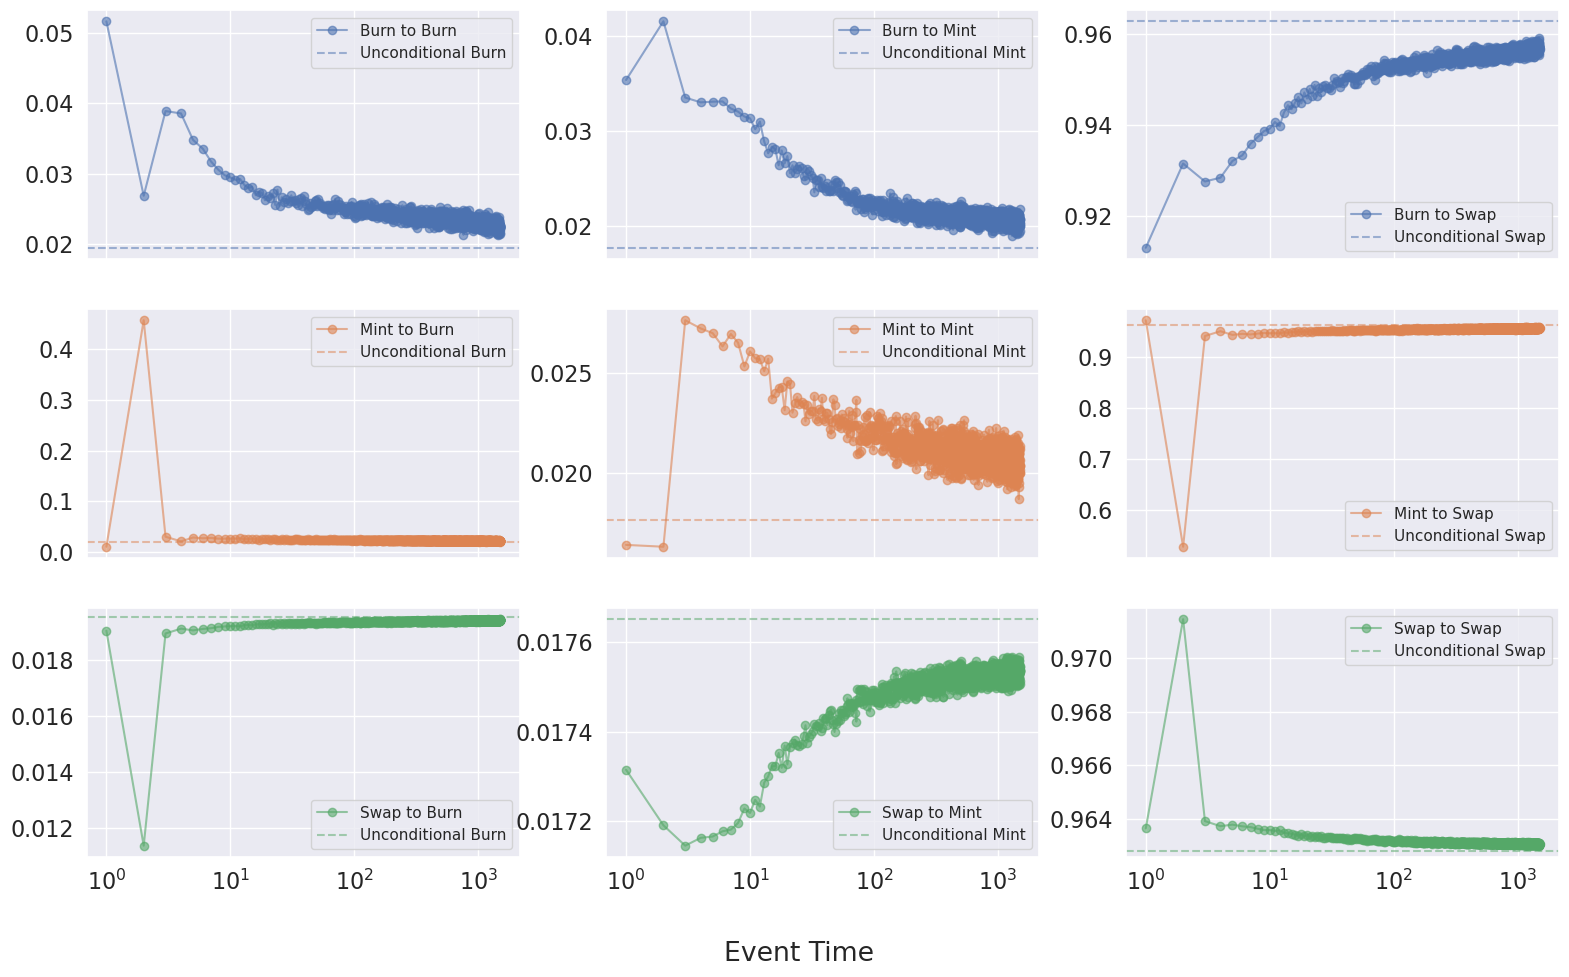

In [9]:
# Extract the transitions for plotting 
unconditional_burn = probabilities_dict[1].loc['Unconditional', 'Burn'] 
unconditional_mint = probabilities_dict[1].loc['Unconditional', 'Mint'] 
unconditional_swap = probabilities_dict[1].loc['Unconditional', 'Swap'] 
 
burn_to_burn = [probabilities_dict[shift].loc['Burn', 'Burn'] for shift in shifts] 
burn_to_mint = [probabilities_dict[shift].loc['Burn', 'Mint'] for shift in shifts] 
burn_to_swap = [probabilities_dict[shift].loc['Burn', 'Swap'] for shift in shifts] 
mint_to_burn = [probabilities_dict[shift].loc['Mint', 'Burn'] for shift in shifts] 
mint_to_mint = [probabilities_dict[shift].loc['Mint', 'Mint'] for shift in shifts] 
mint_to_swap = [probabilities_dict[shift].loc['Mint', 'Swap'] for shift in shifts] 
swap_to_burn = [probabilities_dict[shift].loc['Swap', 'Burn'] for shift in shifts] 
swap_to_mint = [probabilities_dict[shift].loc['Swap', 'Mint'] for shift in shifts] 
swap_to_swap = [probabilities_dict[shift].loc['Swap', 'Swap'] for shift in shifts]
 
# Plot the results with gray markers for p-values > 0.05 
fig, ax = plt.subplots(3, 3, figsize=(19, 11), sharex=True) 
 
for i, (transition, title) in enumerate([ 
    (burn_to_burn, 'Burn to Burn'),
    (burn_to_mint, 'Burn to Mint'),
    (burn_to_swap, 'Burn to Swap'),
    (mint_to_burn, 'Mint to Burn'),
    (mint_to_mint, 'Mint to Mint'),
    (mint_to_swap, 'Mint to Swap'),
    (swap_to_burn, 'Swap to Burn'),
    (swap_to_mint, 'Swap to Mint'),
    (swap_to_swap, 'Swap to Swap') ]): 
    row, col = divmod(i, 3) # divmod returns the quotient and the remainder of the division of the first argument by the second
    ax[row, col].plot(shifts, transition, marker='o', linestyle='-', color=sns.color_palette()[row], alpha=0.6, label=title)
    if 'to Burn' in title: 
        ax[row, col].axhline(unconditional_burn, color=sns.color_palette()[row], linestyle='--', label='Unconditional '+title.split(' ')[-1], alpha=0.5) 
    elif 'to Mint' in title: 
        ax[row, col].axhline(unconditional_mint, color=sns.color_palette()[row], linestyle='--', label='Unconditional '+title.split(' ')[-1], alpha=0.5) 
    elif 'to Swap' in title: 
        ax[row, col].axhline(unconditional_swap, color=sns.color_palette()[row], linestyle='--', label='Unconditional '+title.split(' ')[-1], alpha=0.5)
     
    ax[row, col].set_xscale('log')
    ax[row, col].legend()

fig.supxlabel('Event Time') 

#plt.savefig(f'stf_tr_probs_{pool_name}.pdf', format='pdf', bbox_inches='tight', dpi=300)
plt.show()

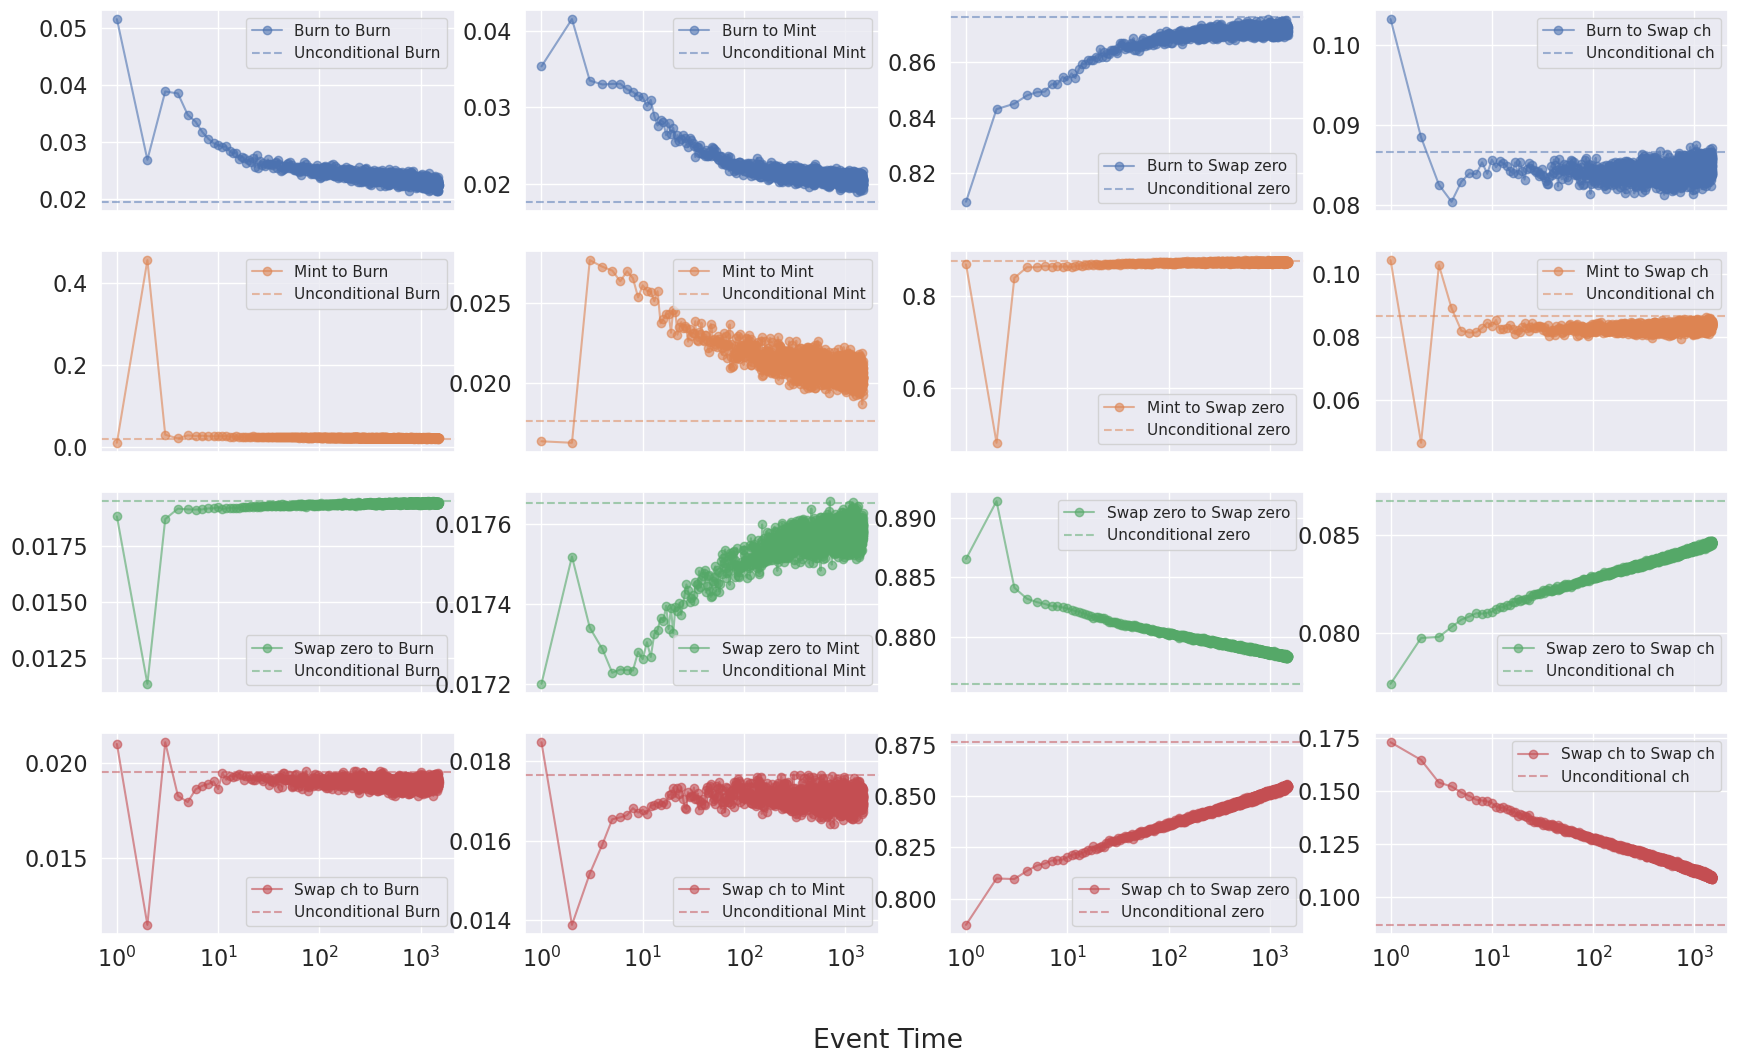

In [10]:
# Extract the transitions for plotting 
unconditional_burn = probabilities_ch_dict[1].loc['Unconditional', 'Burn'] 
unconditional_mint = probabilities_ch_dict[1].loc['Unconditional', 'Mint'] 
unconditional_swap_zero = probabilities_ch_dict[1].loc['Unconditional', 'Swap'] 
unconditional_swap_ch = probabilities_ch_dict[1].loc['Unconditional', 'Swap_ch'] 
 
burn_to_burn = [probabilities_ch_dict[shift].loc['Burn', 'Burn'] for shift in shifts] 
burn_to_mint = [probabilities_ch_dict[shift].loc['Burn', 'Mint'] for shift in shifts] 
burn_to_swap_zero = [probabilities_ch_dict[shift].loc['Burn', 'Swap'] for shift in shifts] 
burn_to_swap_ch = [probabilities_ch_dict[shift].loc['Burn', 'Swap_ch'] for shift in shifts] 
mint_to_burn = [probabilities_ch_dict[shift].loc['Mint', 'Burn'] for shift in shifts] 
mint_to_mint = [probabilities_ch_dict[shift].loc['Mint', 'Mint'] for shift in shifts] 
mint_to_swap_zero = [probabilities_ch_dict[shift].loc['Mint', 'Swap'] for shift in shifts] 
mint_to_swap_ch = [probabilities_ch_dict[shift].loc['Mint', 'Swap_ch'] for shift in shifts] 
swap_zero_to_burn = [probabilities_ch_dict[shift].loc['Swap', 'Burn'] for shift in shifts] 
swap_zero_to_mint = [probabilities_ch_dict[shift].loc['Swap', 'Mint'] for shift in shifts] 
swap_zero_to_swap_zero = [probabilities_ch_dict[shift].loc['Swap', 'Swap'] for shift in shifts]
swap_zero_to_swap_ch = [probabilities_ch_dict[shift].loc['Swap', 'Swap_ch'] for shift in shifts] 
swap_ch_to_mint = [probabilities_ch_dict[shift].loc['Swap_ch', 'Mint'] for shift in shifts] 
swap_ch_to_burn = [probabilities_ch_dict[shift].loc['Swap_ch', 'Burn'] for shift in shifts] 
swap_ch_to_swap_zero = [probabilities_ch_dict[shift].loc['Swap_ch', 'Swap'] for shift in shifts] 
swap_ch_to_swap_ch = [probabilities_ch_dict[shift].loc['Swap_ch', 'Swap_ch'] for shift in shifts] 
 
# Plot the results with gray markers for p-values > 0.05 
fig, ax = plt.subplots(4, 4, figsize=(21, 12), sharex=True) 
 
for i, (transition, title) in enumerate([ 
    (burn_to_burn, 'Burn to Burn'),
    (burn_to_mint, 'Burn to Mint'),
    (burn_to_swap_zero, 'Burn to Swap zero'),
    (burn_to_swap_ch, 'Burn to Swap ch'),
    (mint_to_burn, 'Mint to Burn'),
    (mint_to_mint, 'Mint to Mint'),
    (mint_to_swap_zero, 'Mint to Swap zero'),
    (mint_to_swap_ch, 'Mint to Swap ch'),
    (swap_zero_to_burn, 'Swap zero to Burn'),
    (swap_zero_to_mint, 'Swap zero to Mint'),
    (swap_zero_to_swap_zero, 'Swap zero to Swap zero'), 
    (swap_zero_to_swap_ch, 'Swap zero to Swap ch'), 
    (swap_ch_to_burn, 'Swap ch to Burn'), 
    (swap_ch_to_mint, 'Swap ch to Mint'), 
    (swap_ch_to_swap_zero, 'Swap ch to Swap zero'), 
    (swap_ch_to_swap_ch, 'Swap ch to Swap ch') ]): 
    row, col = divmod(i, 4) # divmod returns the quotient and the remainder of the division of the first argument by the second
    ax[row, col].plot(shifts, transition, marker='o', linestyle='-', color=sns.color_palette()[row], alpha=0.6, label=title)
    if 'to Burn' in title: 
        ax[row, col].axhline(unconditional_burn, color=sns.color_palette()[row], linestyle='--', label='Unconditional '+title.split(' ')[-1], alpha=0.5) 
    elif 'to Mint' in title: 
        ax[row, col].axhline(unconditional_mint, color=sns.color_palette()[row], linestyle='--', label='Unconditional '+title.split(' ')[-1], alpha=0.5) 
    elif 'to Swap zero' in title: 
        ax[row, col].axhline(unconditional_swap_zero, color=sns.color_palette()[row], linestyle='--', label='Unconditional '+title.split(' ')[-1], alpha=0.5)
    elif 'to Swap ch' in title: 
        ax[row, col].axhline(unconditional_swap_ch, color=sns.color_palette()[row], linestyle='--', label='Unconditional '+title.split(' ')[-1], alpha=0.5)
     
    ax[row, col].set_xscale('log')
    ax[row, col].legend()

fig.supxlabel('Event Time') 

#plt.savefig(f'stf_tr_probs_{pool_name}.pdf', format='pdf', bbox_inches='tight', dpi=300)
plt.show()

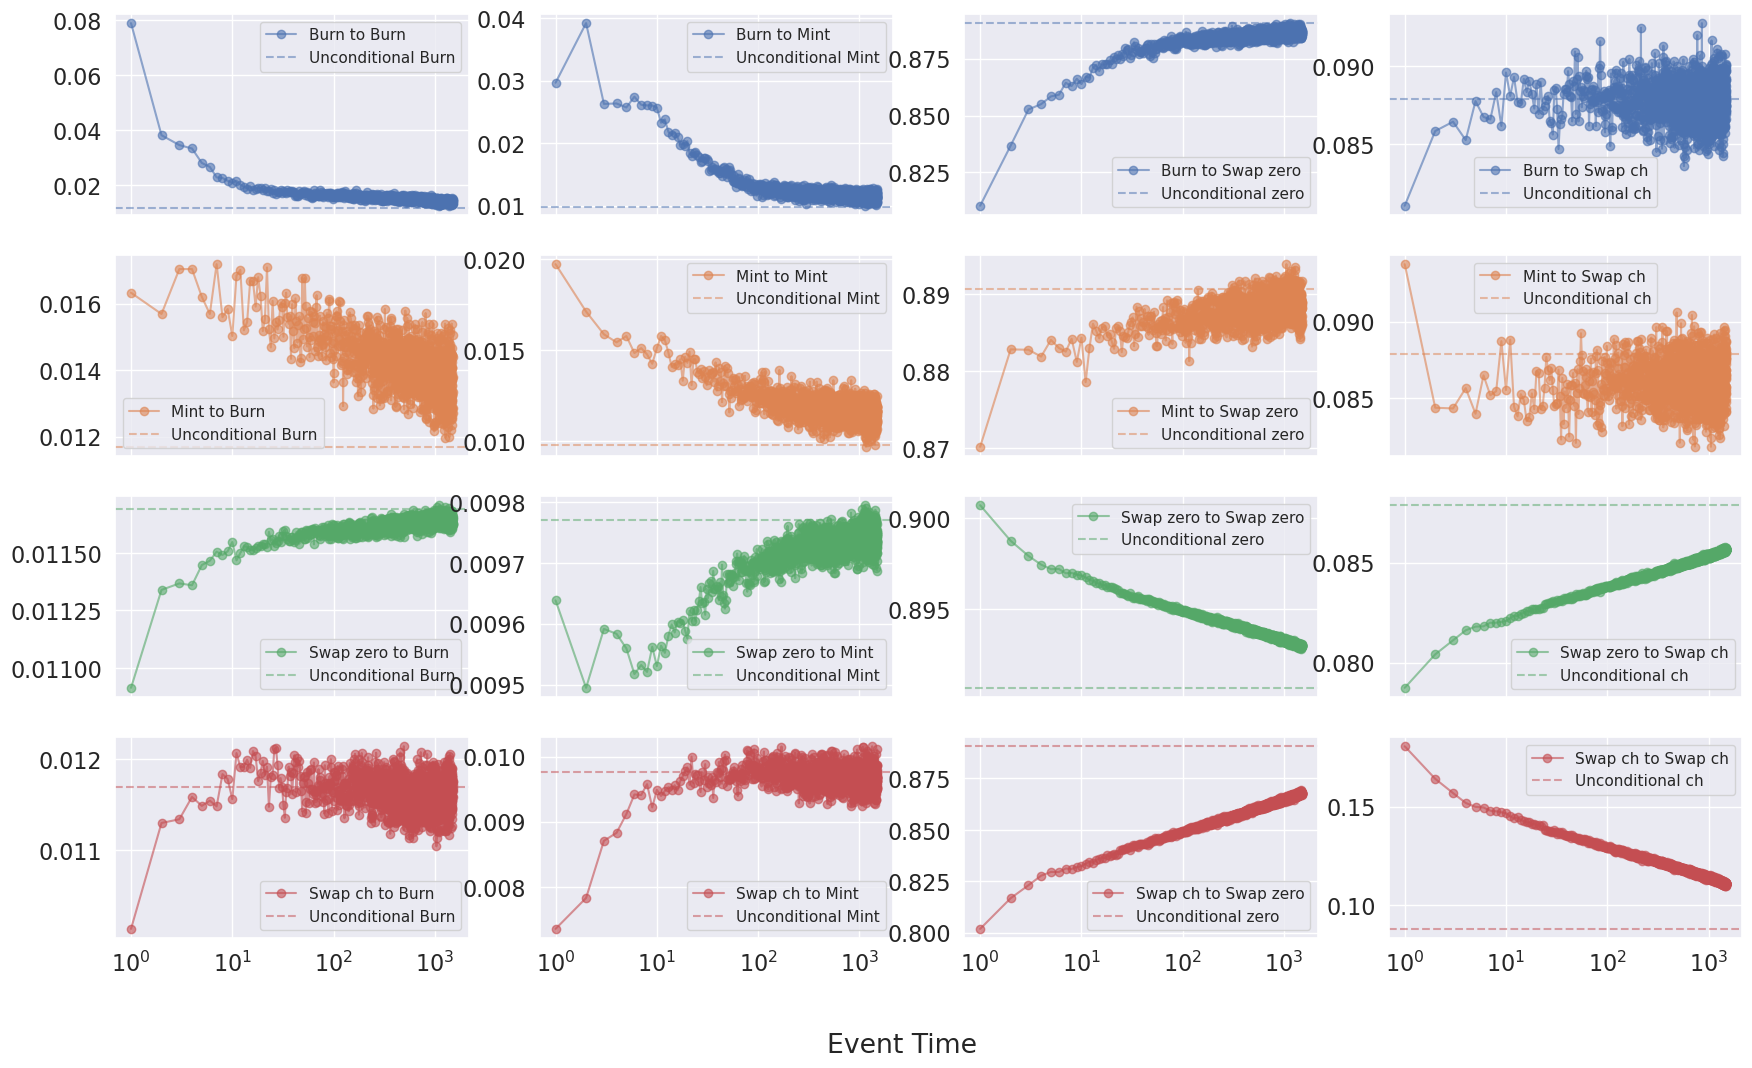

In [11]:

if 'transition_probs_cleaned.pickle' in os.listdir():
    with open('transition_probs_cleaned.pickle', 'rb') as f:
        probabilities_dict, probabilities_ch_dict = pickle.load(f)
    shifts = list(probabilities_dict.keys())
else:
    nlags = 1_500
    shifts = np.arange(1, nlags)
    df_cleaned = df[ df.JIT_flag==0 ]
    
    results = utils_DevTrad.transition_probabilities(
        df_cleaned.Event.values, shifts)
    probabilities_dict = {shift: probabilities for shift, probabilities in zip(shifts, results)}

    results = utils_DevTrad.transition_probabilities(
        df_cleaned.Event.values, shifts, swap_separate=df_cleaned.tick_time.values)
    probabilities_ch_dict = {shift: probabilities for shift, probabilities in zip(shifts, results)}

    with open(f'transition_probs_cleaned.pickle', 'wb') as f: 
        pickle.dump([probabilities_dict, probabilities_ch_dict], f)


# Extract the transitions for plotting 
unconditional_burn = probabilities_ch_dict[1].loc['Unconditional', 'Burn'] 
unconditional_mint = probabilities_ch_dict[1].loc['Unconditional', 'Mint'] 
unconditional_swap_zero = probabilities_ch_dict[1].loc['Unconditional', 'Swap'] 
unconditional_swap_ch = probabilities_ch_dict[1].loc['Unconditional', 'Swap_ch'] 
 
burn_to_burn = [probabilities_ch_dict[shift].loc['Burn', 'Burn'] for shift in shifts] 
burn_to_mint = [probabilities_ch_dict[shift].loc['Burn', 'Mint'] for shift in shifts] 
burn_to_swap_zero = [probabilities_ch_dict[shift].loc['Burn', 'Swap'] for shift in shifts] 
burn_to_swap_ch = [probabilities_ch_dict[shift].loc['Burn', 'Swap_ch'] for shift in shifts] 
mint_to_burn = [probabilities_ch_dict[shift].loc['Mint', 'Burn'] for shift in shifts] 
mint_to_mint = [probabilities_ch_dict[shift].loc['Mint', 'Mint'] for shift in shifts] 
mint_to_swap_zero = [probabilities_ch_dict[shift].loc['Mint', 'Swap'] for shift in shifts] 
mint_to_swap_ch = [probabilities_ch_dict[shift].loc['Mint', 'Swap_ch'] for shift in shifts] 
swap_zero_to_burn = [probabilities_ch_dict[shift].loc['Swap', 'Burn'] for shift in shifts] 
swap_zero_to_mint = [probabilities_ch_dict[shift].loc['Swap', 'Mint'] for shift in shifts] 
swap_zero_to_swap_zero = [probabilities_ch_dict[shift].loc['Swap', 'Swap'] for shift in shifts]
swap_zero_to_swap_ch = [probabilities_ch_dict[shift].loc['Swap', 'Swap_ch'] for shift in shifts] 
swap_ch_to_mint = [probabilities_ch_dict[shift].loc['Swap_ch', 'Mint'] for shift in shifts] 
swap_ch_to_burn = [probabilities_ch_dict[shift].loc['Swap_ch', 'Burn'] for shift in shifts] 
swap_ch_to_swap_zero = [probabilities_ch_dict[shift].loc['Swap_ch', 'Swap'] for shift in shifts] 
swap_ch_to_swap_ch = [probabilities_ch_dict[shift].loc['Swap_ch', 'Swap_ch'] for shift in shifts] 
 
# Plot the results with gray markers for p-values > 0.05 
fig, ax = plt.subplots(4, 4, figsize=(21, 12), sharex=True) 
 
for i, (transition, title) in enumerate([ 
    (burn_to_burn, 'Burn to Burn'),
    (burn_to_mint, 'Burn to Mint'),
    (burn_to_swap_zero, 'Burn to Swap zero'),
    (burn_to_swap_ch, 'Burn to Swap ch'),
    (mint_to_burn, 'Mint to Burn'),
    (mint_to_mint, 'Mint to Mint'),
    (mint_to_swap_zero, 'Mint to Swap zero'),
    (mint_to_swap_ch, 'Mint to Swap ch'),
    (swap_zero_to_burn, 'Swap zero to Burn'),
    (swap_zero_to_mint, 'Swap zero to Mint'),
    (swap_zero_to_swap_zero, 'Swap zero to Swap zero'), 
    (swap_zero_to_swap_ch, 'Swap zero to Swap ch'), 
    (swap_ch_to_burn, 'Swap ch to Burn'), 
    (swap_ch_to_mint, 'Swap ch to Mint'), 
    (swap_ch_to_swap_zero, 'Swap ch to Swap zero'), 
    (swap_ch_to_swap_ch, 'Swap ch to Swap ch') ]): 
    row, col = divmod(i, 4) # divmod returns the quotient and the remainder of the division of the first argument by the second
    ax[row, col].plot(shifts, transition, marker='o', linestyle='-', color=sns.color_palette()[row], alpha=0.6, label=title)
    if 'to Burn' in title: 
        ax[row, col].axhline(unconditional_burn, color=sns.color_palette()[row], linestyle='--', label='Unconditional '+title.split(' ')[-1], alpha=0.5) 
    elif 'to Mint' in title: 
        ax[row, col].axhline(unconditional_mint, color=sns.color_palette()[row], linestyle='--', label='Unconditional '+title.split(' ')[-1], alpha=0.5) 
    elif 'to Swap zero' in title: 
        ax[row, col].axhline(unconditional_swap_zero, color=sns.color_palette()[row], linestyle='--', label='Unconditional '+title.split(' ')[-1], alpha=0.5)
    elif 'to Swap ch' in title: 
        ax[row, col].axhline(unconditional_swap_ch, color=sns.color_palette()[row], linestyle='--', label='Unconditional '+title.split(' ')[-1], alpha=0.5)
     
    ax[row, col].set_xscale('log')
    ax[row, col].legend()

fig.supxlabel('Event Time') 

#plt.savefig(f'stf_tr_probs_cleaned_{pool_name}.pdf', format='pdf', bbox_inches='tight', dpi=300)
plt.show()



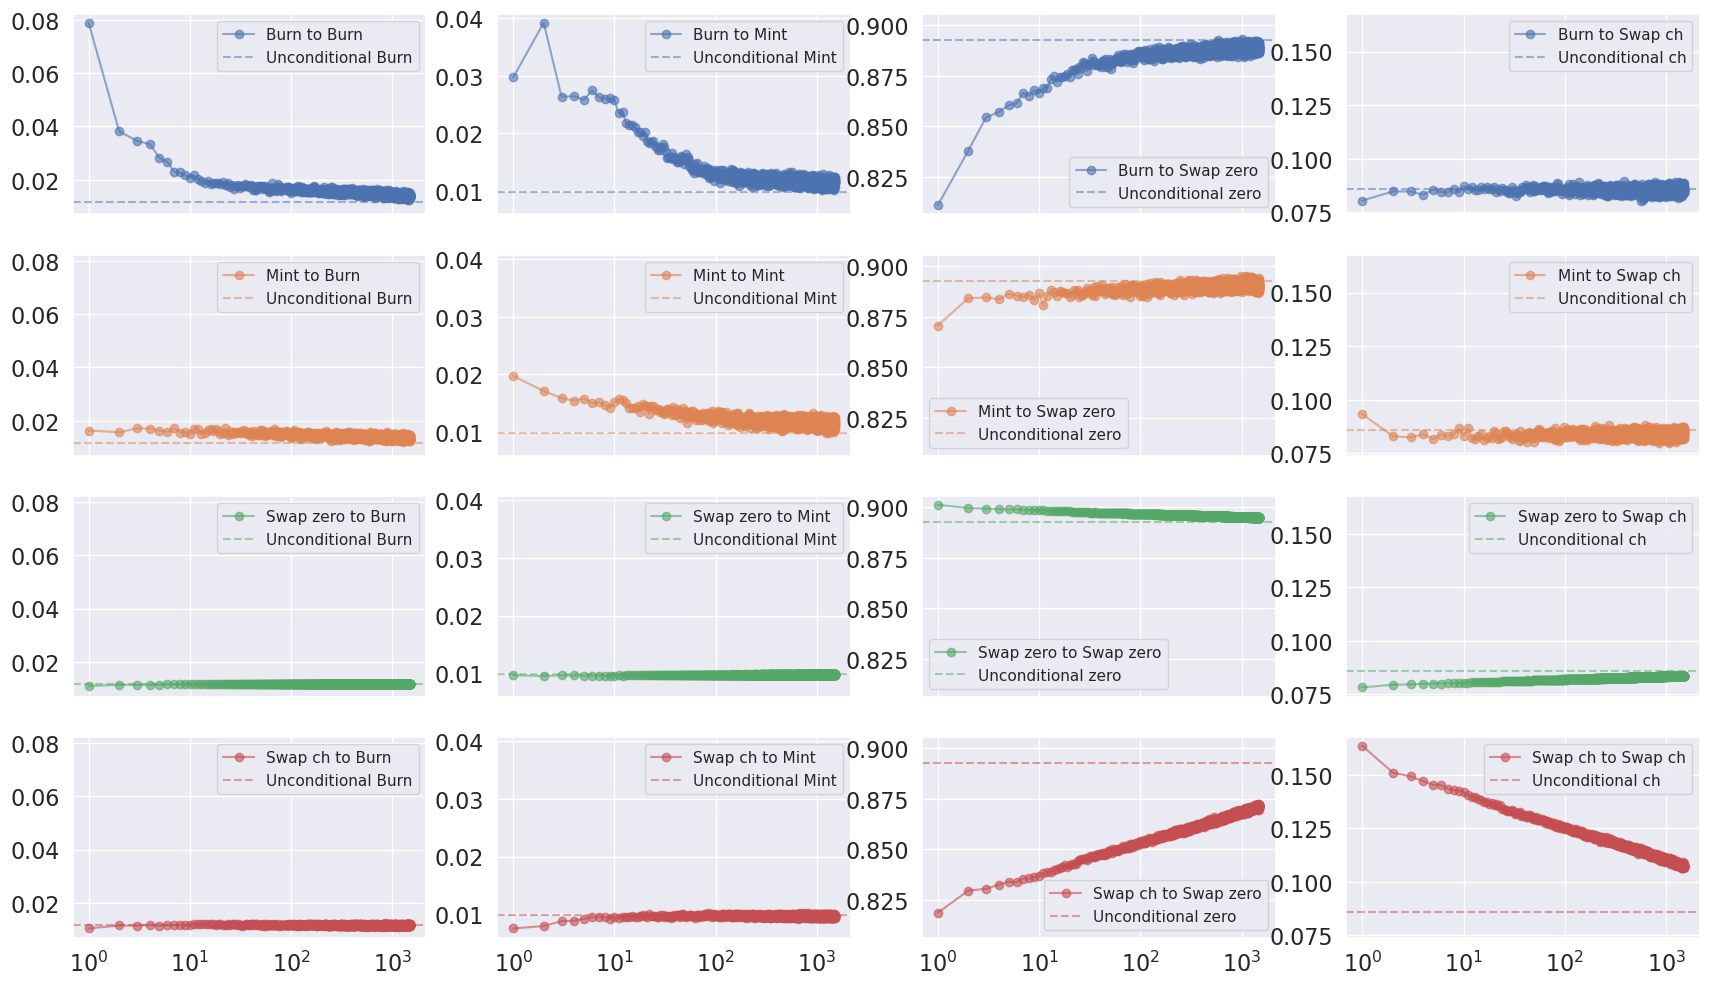

In [ ]:

if 'transition_probs_full_cleaned.pickle' in os.listdir():
    with open('transition_probs_full_cleaned.pickle', 'rb') as f:
        probabilities_dict, probabilities_ch_dict = pickle.load(f)
    shifts = list(probabilities_dict.keys())
else:
    nlags = 1_500
    shifts = np.arange(1, nlags)
    df_cleaned = df[[ val in ['Not', 'Front_Self', 'Victim_Self', 'Back_Self', 'Victim_Gen', 'Victim'] for val in df.sandwich_state ]]
    df_cleaned = df_cleaned[ df_cleaned.JIT_flag==0 ]

    results = utils_DevTrad.transition_probabilities(
        df_cleaned.Event.values, shifts)
    probabilities_dict = {shift: probabilities for shift, probabilities in zip(shifts, results)}

    results = utils_DevTrad.transition_probabilities(
        df_cleaned.Event.values, shifts, swap_separate=df_cleaned.tick_time.values)
    probabilities_ch_dict = {shift: probabilities for shift, probabilities in zip(shifts, results)}

    with open(f'transition_probs_full_cleaned.pickle', 'wb') as f: 
        pickle.dump([probabilities_dict, probabilities_ch_dict], f)


# Extract the transitions for plotting 
unconditional_burn = probabilities_ch_dict[1].loc['Unconditional', 'Burn'] 
unconditional_mint = probabilities_ch_dict[1].loc['Unconditional', 'Mint'] 
unconditional_swap_zero = probabilities_ch_dict[1].loc['Unconditional', 'Swap'] 
unconditional_swap_ch = probabilities_ch_dict[1].loc['Unconditional', 'Swap_ch'] 
 
burn_to_burn = [probabilities_ch_dict[shift].loc['Burn', 'Burn'] for shift in shifts] 
burn_to_mint = [probabilities_ch_dict[shift].loc['Burn', 'Mint'] for shift in shifts] 
burn_to_swap_zero = [probabilities_ch_dict[shift].loc['Burn', 'Swap'] for shift in shifts] 
burn_to_swap_ch = [probabilities_ch_dict[shift].loc['Burn', 'Swap_ch'] for shift in shifts] 
mint_to_burn = [probabilities_ch_dict[shift].loc['Mint', 'Burn'] for shift in shifts] 
mint_to_mint = [probabilities_ch_dict[shift].loc['Mint', 'Mint'] for shift in shifts] 
mint_to_swap_zero = [probabilities_ch_dict[shift].loc['Mint', 'Swap'] for shift in shifts] 
mint_to_swap_ch = [probabilities_ch_dict[shift].loc['Mint', 'Swap_ch'] for shift in shifts] 
swap_zero_to_burn = [probabilities_ch_dict[shift].loc['Swap', 'Burn'] for shift in shifts] 
swap_zero_to_mint = [probabilities_ch_dict[shift].loc['Swap', 'Mint'] for shift in shifts] 
swap_zero_to_swap_zero = [probabilities_ch_dict[shift].loc['Swap', 'Swap'] for shift in shifts]
swap_zero_to_swap_ch = [probabilities_ch_dict[shift].loc['Swap', 'Swap_ch'] for shift in shifts] 
swap_ch_to_mint = [probabilities_ch_dict[shift].loc['Swap_ch', 'Mint'] for shift in shifts] 
swap_ch_to_burn = [probabilities_ch_dict[shift].loc['Swap_ch', 'Burn'] for shift in shifts] 
swap_ch_to_swap_zero = [probabilities_ch_dict[shift].loc['Swap_ch', 'Swap'] for shift in shifts] 
swap_ch_to_swap_ch = [probabilities_ch_dict[shift].loc['Swap_ch', 'Swap_ch'] for shift in shifts] 
 
# Plot the results with gray markers for p-values > 0.05 
fig, ax = plt.subplots(4, 4, figsize=(21, 12), sharex=True, sharey='col') 
 
for i, (transition, title) in enumerate([ 
    (burn_to_burn, 'Burn to Burn'),
    (burn_to_mint, 'Burn to Mint'),
    (burn_to_swap_zero, 'Burn to Swap zero'),
    (burn_to_swap_ch, 'Burn to Swap ch'),
    (mint_to_burn, 'Mint to Burn'),
    (mint_to_mint, 'Mint to Mint'),
    (mint_to_swap_zero, 'Mint to Swap zero'),
    (mint_to_swap_ch, 'Mint to Swap ch'),
    (swap_zero_to_burn, 'Swap zero to Burn'),
    (swap_zero_to_mint, 'Swap zero to Mint'),
    (swap_zero_to_swap_zero, 'Swap zero to Swap zero'), 
    (swap_zero_to_swap_ch, 'Swap zero to Swap ch'), 
    (swap_ch_to_burn, 'Swap ch to Burn'), 
    (swap_ch_to_mint, 'Swap ch to Mint'), 
    (swap_ch_to_swap_zero, 'Swap ch to Swap zero'), 
    (swap_ch_to_swap_ch, 'Swap ch to Swap ch') ]): 
    row, col = divmod(i, 4) # divmod returns the quotient and the remainder of the division of the first argument by the second
    ax[row, col].plot(shifts, transition, marker='o', linestyle='-', color=sns.color_palette()[row], alpha=0.6, label=title)
    if 'to Burn' in title: 
        ax[row, col].axhline(unconditional_burn, color=sns.color_palette()[row], linestyle='--', label='Unconditional '+title.split(' ')[-1], alpha=0.5) 
    elif 'to Mint' in title: 
        ax[row, col].axhline(unconditional_mint, color=sns.color_palette()[row], linestyle='--', label='Unconditional '+title.split(' ')[-1], alpha=0.5) 
    elif 'to Swap zero' in title: 
        ax[row, col].axhline(unconditional_swap_zero, color=sns.color_palette()[row], linestyle='--', label='Unconditional '+title.split(' ')[-1], alpha=0.5)
    elif 'to Swap ch' in title: 
        ax[row, col].axhline(unconditional_swap_ch, color=sns.color_palette()[row], linestyle='--', label='Unconditional '+title.split(' ')[-1], alpha=0.5)

    ax[row, col].set_xscale('log')
    ax[row, col].legend()

#plt.savefig(f'stf_tr_probs_full_cleaned_{pool_name}.pdf', format='pdf', bbox_inches='tight', dpi=300)
plt.show()


# Intra-day

data_window_grouped: (105264,)


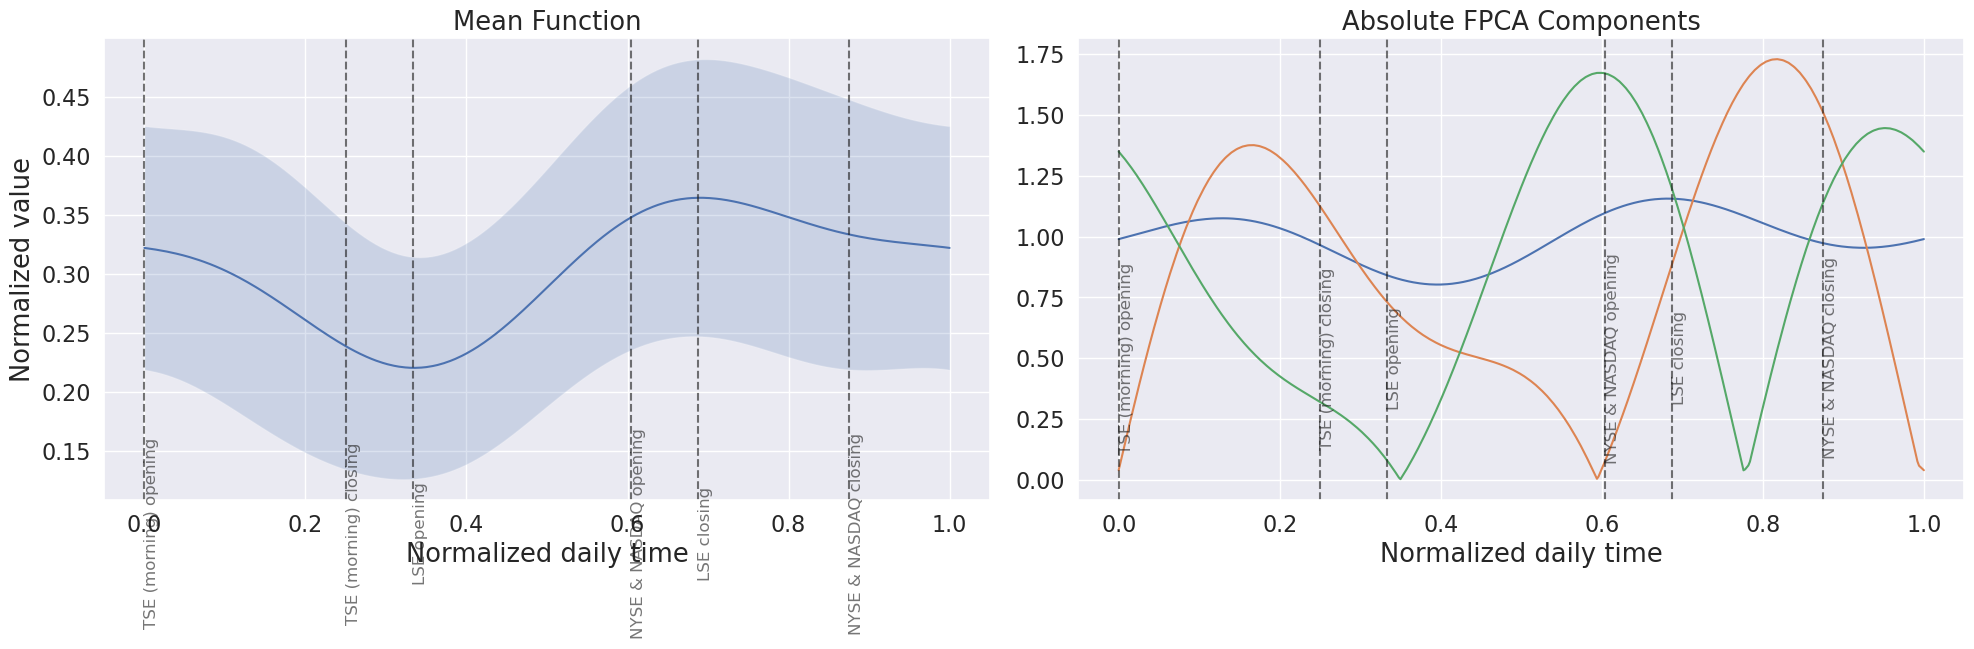

[0.55856576 0.17312738 0.11888079]
0.8505739261904615


In [ ]:

_, _, data = utils_DevTrad.distribution_daily(df, '10min', "event")
data_rescaled = utils_DevTrad.rescale_data(data, interval=(0, 1))

N, M = data_rescaled.shape
(normalized_stock_markets, fd_mean, fd_std, components,
    ex_var_ratio) = utils_DevTrad.periodic_analysis(
        data_rescaled, 3)

fig, ax = plt.subplots(1, 2, figsize=(24, 6), gridspec_kw={'wspace':0.1})
fd_mean.plot(axes=ax[0])
# compute the confidence intervals of fd_smooth.mean()
mean_values = fd_mean.data_matrix.flatten()
std_values = fd_std.flatten()
ax[0].fill_between(fd_mean.grid_points[0], mean_values-1*std_values, mean_values+1*std_values, alpha=0.2)
ax[0].set_title("Mean Function")
for (market, hours) in normalized_stock_markets.items():
    ax[0].axvline(hours[0], color='k', linestyle='--', label=f"{market} opening", alpha=0.6)
    ax[0].axvline(hours[1], color='k', linestyle='--', label=f"{market} closing", alpha=0.6)
    # add text along the lines
    ax[0].text(hours[0], 0.08, f"{market} opening", color='k', rotation=90, va='center', fontsize=12, alpha=0.6)
    ax[0].text(hours[1], 0.08, f"{market} closing", color='k', rotation=90, va='center', fontsize=12, alpha=0.6)
ax[0].grid(True)
ax[0].set_xlabel('Normalized daily time')
ax[0].set_ylabel('Normalized value')

# Perform FPCA
np.abs(components).plot(axes=ax[1])
ax[1].set_title("Absolute FPCA Components")
# Add vertical lines for the opening hours of major stock markets
for (market, hours) in normalized_stock_markets.items():
    ax[1].axvline(hours[0], color='k', linestyle='--', label=f"{market} opening", alpha=0.6)
    ax[1].axvline(hours[1], color='k', linestyle='--', label=f"{market} closing", alpha=0.6)
    # add text along the lines
    ax[1].text(hours[0], 0.5, f"{market} opening", color='k', rotation=90, va='center', fontsize=12, alpha=0.6)
    ax[1].text(hours[1], 0.5, f"{market} closing", color='k', rotation=90, va='center', fontsize=12, alpha=0.6)
ax[1].grid(True)
ax[1].set_xlabel('Normalized daily time')
#plt.savefig(f'images/{pool_name}/fpcs_mean_fpca.pdf', format='pdf', dpi=300)
plt.show()

# Explained variance
print(ex_var_ratio)
print(ex_var_ratio.sum())


data_window_grouped: (105264,)
There are NaN values in the data_window_grouped resampled. This means that sometimes there have not been any events in the provided time window. I will fill these NaN values with 0. Total NaN values: 13


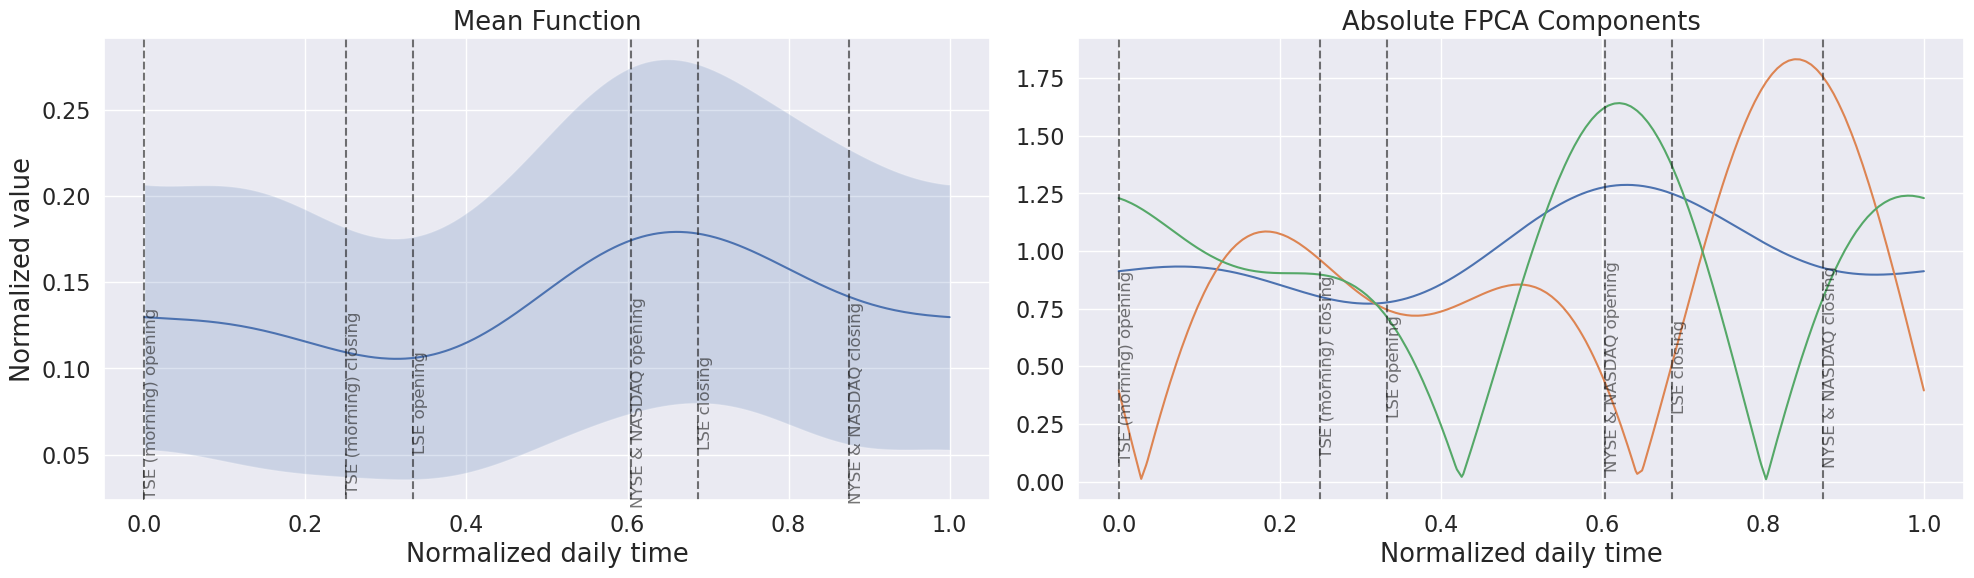

[0.71712468 0.11085993 0.07380915]
0.9017937539157451


In [ ]:

_, _, data = utils_DevTrad.distribution_daily(df, '10min', "std")
data_rescaled = utils_DevTrad.rescale_data(data, interval=(0, 1))

N, M = data_rescaled.shape
(normalized_stock_markets, fd_mean, fd_std, components,
    ex_var_ratio) = utils_DevTrad.periodic_analysis(
        data_rescaled, 3)

fig, ax = plt.subplots(1, 2, figsize=(24, 6), gridspec_kw={'wspace':0.1})
fd_mean.plot(axes=ax[0])
# compute the confidence intervals of fd_smooth.mean()
mean_values = fd_mean.data_matrix.flatten()
std_values = fd_std.flatten()
ax[0].fill_between(fd_mean.grid_points[0], mean_values-1*std_values, mean_values+1*std_values, alpha=0.2)
ax[0].set_title("Mean Function")
for (market, hours) in normalized_stock_markets.items():
    ax[0].axvline(hours[0], color='k', linestyle='--', label=f"{market} opening", alpha=0.6)
    ax[0].axvline(hours[1], color='k', linestyle='--', label=f"{market} closing", alpha=0.6)
    # add text along the lines
    ax[0].text(hours[0], 0.08, f"{market} opening", color='k', rotation=90, va='center', fontsize=12, alpha=0.6)
    ax[0].text(hours[1], 0.08, f"{market} closing", color='k', rotation=90, va='center', fontsize=12, alpha=0.6)
ax[0].grid(True)
ax[0].set_xlabel('Normalized daily time')
ax[0].set_ylabel('Normalized value')

# Perform FPCA
np.abs(components).plot(axes=ax[1])
ax[1].set_title("Absolute FPCA Components")
# Add vertical lines for the opening hours of major stock markets
for (market, hours) in normalized_stock_markets.items():
    ax[1].axvline(hours[0], color='k', linestyle='--', label=f"{market} opening", alpha=0.6)
    ax[1].axvline(hours[1], color='k', linestyle='--', label=f"{market} closing", alpha=0.6)
    # add text along the lines
    ax[1].text(hours[0], 0.5, f"{market} opening", color='k', rotation=90, va='center', fontsize=12, alpha=0.6)
    ax[1].text(hours[1], 0.5, f"{market} closing", color='k', rotation=90, va='center', fontsize=12, alpha=0.6)
ax[1].grid(True)
ax[1].set_xlabel('Normalized daily time')
#plt.savefig(f'images/{pool_name}/fpcs_mean_fpca.pdf', format='pdf', dpi=300)
plt.show()

# Explained variance
print(ex_var_ratio)
print(ex_var_ratio.sum())

# Fat-tail

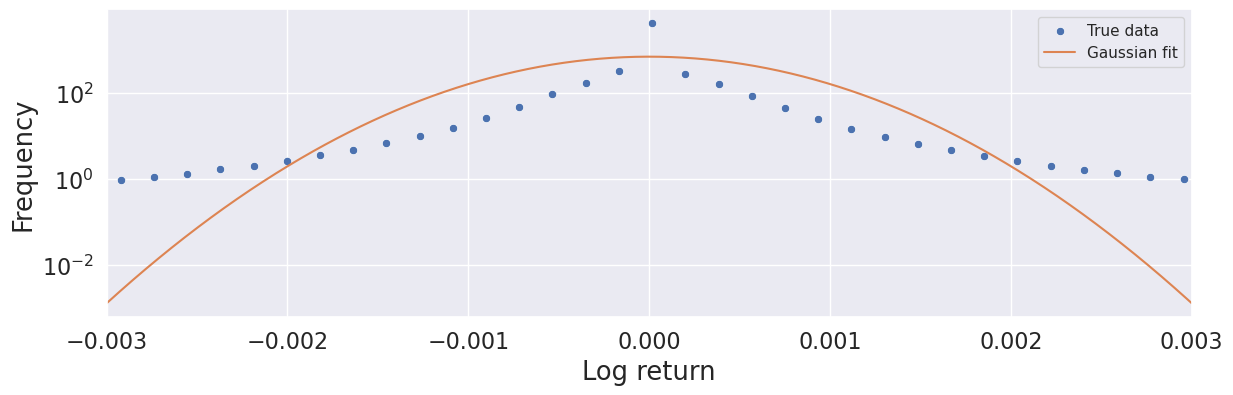

In [ ]:

x_train = np.log(df_swap.price.values)
x_train = x_train[1:] - x_train[:-1]

from scipy.stats import norm

hist, bin_edges = np.histogram(x_train, bins=1000, density=True)

norm_pars = norm.fit(x_train)
norm_obs = np.linspace(-0.003, 0.003, 1_000)
norm_freq = norm.pdf(norm_obs, *norm_pars)

fig, ax = plt.subplots(1, 1, figsize=(14, 4))
ax.set_yscale('log')
ax.set_xlim(-0.003, 0.003)
ax.set_xlabel('Log return')
ax.set_ylabel('Frequency')

sns.scatterplot(x=(bin_edges[1:] + bin_edges[:-1])/2, y=hist, ax=ax, label='True data')
sns.lineplot(x=norm_obs, y=norm_freq, ax=ax, c=sns.color_palette()[1], label='Gaussian fit')

#plt.savefig(f'stf_fat_tails_event_{pool_name}.pdf', format='pdf', bbox_inches='tight', dpi=300)
plt.show()


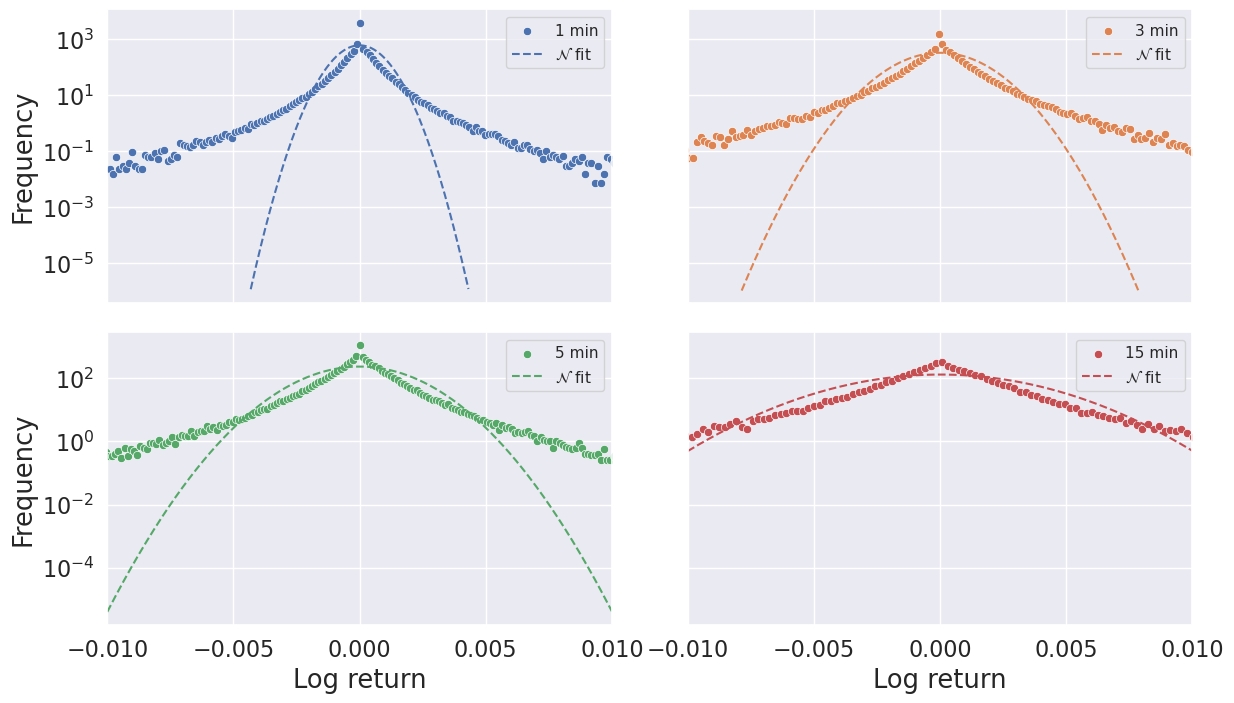

In [ ]:

from scipy.stats import norm

abs_b = 0.010
lb, ub = -abs_b, abs_b

cap = 1e-6

fig, ax = plt.subplots(2, 2, figsize=(14, 8), sharex=True, gridspec_kw={'wspace':0.15,'hspace':0.1})#, sharey=True)

for n_p, n_min in enumerate([1, 3, 5, 15]):
    n_r, n_c = n_p // 2, n_p % 2

    ax[n_r, n_c].set_yscale('log')
    ax[n_r, n_c].set_xlim(lb, ub)

    x_train = np.log(df_swap.price.resample(f'{n_min}min').last())
    x_train = x_train.ffill().values
    x_train = x_train[1:] - x_train[:-1]
    hist, bin_edges = np.histogram(x_train, bins=1000, density=True)

    norm_pars = norm.fit(x_train)
    norm_obs = np.linspace(lb, ub, 1_000)
    norm_freq = norm.pdf(norm_obs, *norm_pars)

    sns.scatterplot(x=(bin_edges[1:] + bin_edges[:-1])/2, y=hist, ax=ax[n_r, n_c], label=f'{n_min} min', c=sns.color_palette()[n_p])
    sns.lineplot(x=norm_obs[norm_freq>cap], y=norm_freq[norm_freq>cap], ax=ax[n_r, n_c], linestyle='--', c=sns.color_palette()[n_p], label=r'$\mathcal{N}$ fit')

    ax[n_r, n_c].legend(loc="upper right")

ax[0, 1].sharey(ax[0, 0])  # Share y-axis for the first row
ax[1, 1].sharey(ax[1, 0])  # Share y-axis for the second row

ax[0, 1].tick_params(axis="y", left=False, labelleft=False)
ax[1, 1].tick_params(axis="y", left=False, labelleft=False)

ax[1, 0].set_xlabel('Log return')
ax[1, 1].set_xlabel('Log return')
ax[0, 0].set_ylabel('Frequency')
ax[1, 0].set_ylabel('Frequency')

#plt.savefig(f'stf_fat_tails_min_{pool_name}.pdf', format='pdf', bbox_inches='tight', dpi=300)
plt.show()


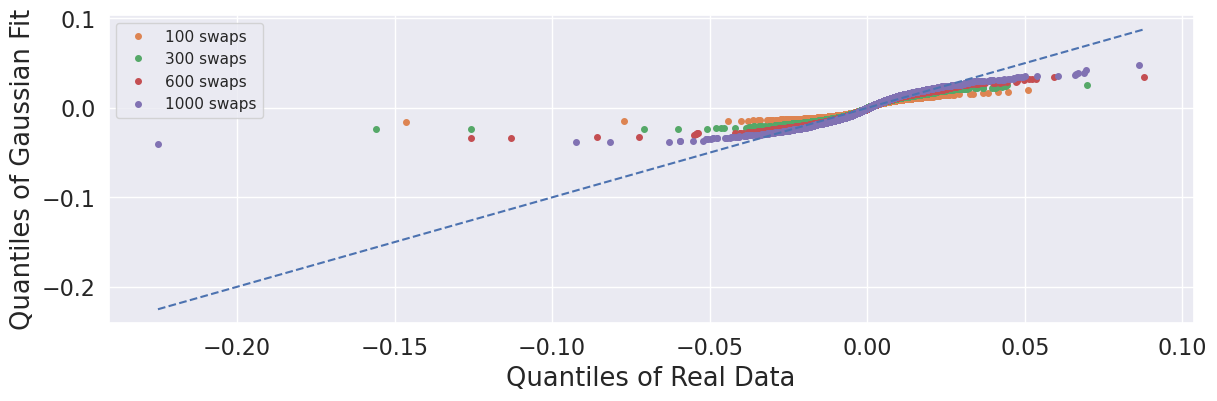

In [ ]:

from scipy.stats import norm

x_min, x_max = np.inf, -np.inf

fig, ax = plt.subplots(1, 1, figsize=(14, 4))

n_blocks = 100

x_train = np.log(df_swap.price.values)
x_train = x_train[::n_blocks]
x_train = x_train[1:] - x_train[:-1]

norm_pars = norm.fit(x_train)
norm_sample = norm.rvs(*norm_pars, size=len(x_train))

y_train_sorted = np.sort(x_train)
gen_sorted = np.sort(norm_sample)

ax.plot(
    y_train_sorted, gen_sorted, 'o', markersize=4,
    c=sns.color_palette()[1], label=f'{n_blocks} swaps')
x_min = np.min([x_min, y_train_sorted.min()])
x_max = np.max([x_max, y_train_sorted.max()])

n_blocks = 300

x_train = np.log(df_swap.price.values)
x_train = x_train[::n_blocks]
x_train = x_train[1:] - x_train[:-1]

norm_pars = norm.fit(x_train)
norm_sample = norm.rvs(*norm_pars, size=len(x_train))

y_train_sorted = np.sort(x_train)
gen_sorted = np.sort(norm_sample)

ax.plot(
    y_train_sorted, gen_sorted, 'o', markersize=4,
    c=sns.color_palette()[2], label=f'{n_blocks} swaps')
x_min = np.min([x_min, y_train_sorted.min()])
x_max = np.max([x_max, y_train_sorted.max()])

n_blocks = 600

x_train = np.log(df_swap.price.values)
x_train = x_train[::n_blocks]
x_train = x_train[1:] - x_train[:-1]

norm_pars = norm.fit(x_train)
norm_sample = norm.rvs(*norm_pars, size=len(x_train))

y_train_sorted = np.sort(x_train)
gen_sorted = np.sort(norm_sample)

ax.plot(
    y_train_sorted, gen_sorted, 'o', markersize=4,
    c=sns.color_palette()[3], label=f'{n_blocks} swaps')
x_min = np.min([x_min, y_train_sorted.min()])
x_max = np.max([x_max, y_train_sorted.max()])

n_blocks = 1000

x_train = np.log(df_swap.price.values)
x_train = x_train[::n_blocks]
x_train = x_train[1:] - x_train[:-1]

norm_pars = norm.fit(x_train)
norm_sample = norm.rvs(*norm_pars, size=len(x_train))

y_train_sorted = np.sort(x_train)
gen_sorted = np.sort(norm_sample)

ax.plot(
    y_train_sorted, gen_sorted, 'o', markersize=4,
    c=sns.color_palette()[4], label=f'{n_blocks} swaps')
x_min = np.min([x_min, y_train_sorted.min()])
x_max = np.max([x_max, y_train_sorted.max()])


ax.plot([x_min, x_max], [x_min, x_max], 'r--', c=sns.color_palette()[0])
# Customize the plot
ax.set_xlabel('Quantiles of Real Data')
ax.set_ylabel('Quantiles of Gaussian Fit')
ax.legend()

#plt.savefig(f'stf_fat_tails_event_agg_{pool_name}.pdf', format='pdf', bbox_inches='tight', dpi=300)
plt.show()

# Autocorrelation - Returns

In [19]:

def count_significant(acf_vals, up_bound, low_bound):
    pos_acf, neg_acf = 0, 0
    for val, up_bound, low_bound in zip(
        acf_vals, up_bound, low_bound):
        if val > up_bound:
            pos_acf += 1
        if val < low_bound:
            neg_acf += 1
    return pos_acf, neg_acf


Swap-time, there are 6 positive and 10 negative ACF values out of 20
Tick-time, there are 7 positive and 10 negative ACF values out of 20
Clock-time (30 seconds), there are 13 positive and 7 negative ACF values out of 20
Clock-time (1 minutes), there are 11 positive and 5 negative ACF values out of 20
Clock-time (5 minutes), there are 4 positive and 7 negative ACF values out of 20


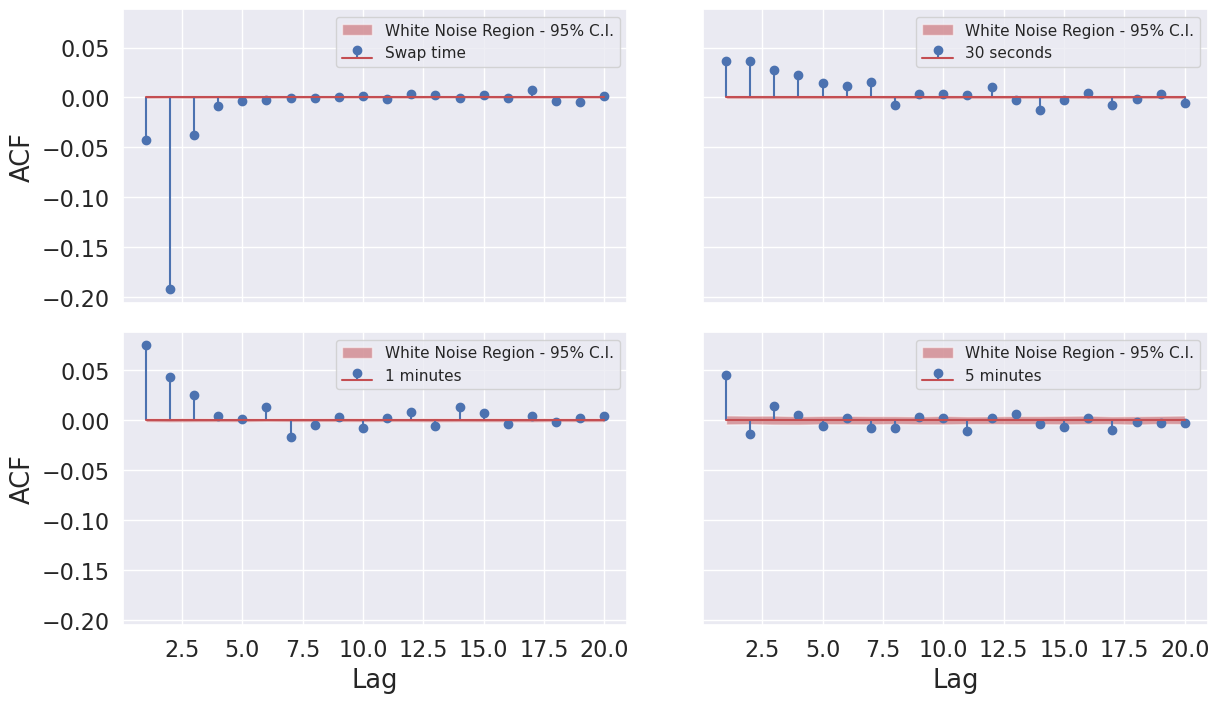

In [ ]:

from statsmodels.tsa.stattools import acf

nlags = 20

fig, ax = plt.subplots(2, 2, figsize=(14, 8), sharex=True, sharey=True, gridspec_kw={'wspace':0.15,'hspace':0.1})#, sharey=True)

# Event time
n_r, n_c = 0, 0

x_train = np.log(df_swap.price.values)
x_train = x_train[1:] - x_train[:-1]
acf_block = acf(x_train, nlags=nlags)

if 'bounds_event.pickle' in os.listdir():
    with open('bounds_event.pickle', 'rb') as f:
        _, lower_white_noise_bound, upper_white_noise_bound = pickle.load(f)
    bootstrap_flag = False
else:
    bootstrap_array, lower_white_noise_bound,upper_white_noise_bound = dict(), dict(), dict()
    bootstrap_array['event'] = utils_DevTrad.bootstrap_iid_autocorr(x_train, 500, nlags)
    lower_white_noise_bound['event'] = np.percentile(bootstrap_array['event'], 2.5, axis=0)
    upper_white_noise_bound['event'] = np.percentile(bootstrap_array['event'], 97.5, axis=0)
    bootstrap_flag = True

pos_acf, neg_acf = count_significant(
    acf_block[1:],
    upper_white_noise_bound['event'],
    lower_white_noise_bound['event'] )
print('Swap-time, there are', pos_acf, 'positive and', neg_acf, 'negative ACF values out of', nlags)

utils_DevTrad.plot_acf(
        acf_block, nlags, ax[n_r, n_c], label="Swap time",
        up_bound=upper_white_noise_bound['event'],
        low_bound=lower_white_noise_bound['event'])
if n_r == 1:
    ax[n_r, n_c].set_xlabel('Lag')
if n_c == 0:
    ax[n_r, n_c].set_ylabel('ACF')

# Tick time
x_train = np.log(df_swap.price.values)
x_train = x_train[ df_swap.tick_time!=0 ]
x_train = x_train[1:] - x_train[:-1]
acf_block = acf(x_train, nlags=nlags)

if bootstrap_flag:
    bootstrap_array['tick'] = utils_DevTrad.bootstrap_iid_autocorr(x_train, 500, nlags)
    lower_white_noise_bound['tick'] = np.percentile(bootstrap_array['tick'], 2.5, axis=0)
    upper_white_noise_bound['tick'] = np.percentile(bootstrap_array['tick'], 97.5, axis=0)

pos_acf, neg_acf = count_significant(
    acf_block[1:],
    upper_white_noise_bound['tick'],
    lower_white_noise_bound['tick'] )
print('Tick-time, there are', pos_acf, 'positive and', neg_acf, 'negative ACF values out of', nlags)

for n_p, n_min in enumerate([0, 1, 5]):
    n_r, n_c = (n_p+1) // 2, (n_p+1) % 2

    if n_min == 0:
        x_train = np.log(df_swap.price.resample('30s').last())
        x_train = x_train.ffill().values
        x_train = x_train[1:] - x_train[:-1]
    else:
        x_train = np.log(df_swap.price.resample(f'{n_min}min').last())
        x_train = x_train.ffill().values
        x_train = x_train[1:] - x_train[:-1]
    acf_block = acf(x_train, nlags=nlags)

    if bootstrap_flag:
        bootstrap_array[n_min] = utils_DevTrad.bootstrap_iid_autocorr(x_train, 500, nlags)
        lower_white_noise_bound[n_min] = np.percentile(bootstrap_array[n_min], 2.5, axis=0)
        upper_white_noise_bound[n_min] = np.percentile(bootstrap_array[n_min], 97.5, axis=0)

    pos_acf, neg_acf = count_significant(
        acf_block[1:],
        upper_white_noise_bound[n_min][1:],
        lower_white_noise_bound[n_min][1:] )
    if n_min == 0:
        print(f'Clock-time (30 seconds), there are', pos_acf, 'positive and', neg_acf, 'negative ACF values out of', nlags)
    else:
        print(f'Clock-time ({n_min} minutes), there are', pos_acf, 'positive and', neg_acf, 'negative ACF values out of', nlags)

    if n_min == 0:
        label = '30 seconds'
    else:
        label = f'{n_min} minutes'
        
    utils_DevTrad.plot_acf(
            acf_block, nlags, ax[n_r, n_c], label=label,
            up_bound=upper_white_noise_bound[n_min],
            low_bound=lower_white_noise_bound[n_min])

    if n_r == 1:
        ax[n_r, n_c].set_xlabel('Lag')
    if n_c == 0:
        ax[n_r, n_c].set_ylabel('ACF')

ax[0, 1].tick_params(axis="y", left=False, labelleft=False)
ax[1, 1].tick_params(axis="y", left=False, labelleft=False)

#plt.savefig(f'stf_acf_{pool_name}.pdf', format='pdf', bbox_inches='tight', dpi=300)
plt.show()

if bootstrap_flag:
    with open('bounds_event.pickle', 'wb') as f:
        pickle.dump([bootstrap_array, lower_white_noise_bound, upper_white_noise_bound], f)
    del(bootstrap_array)


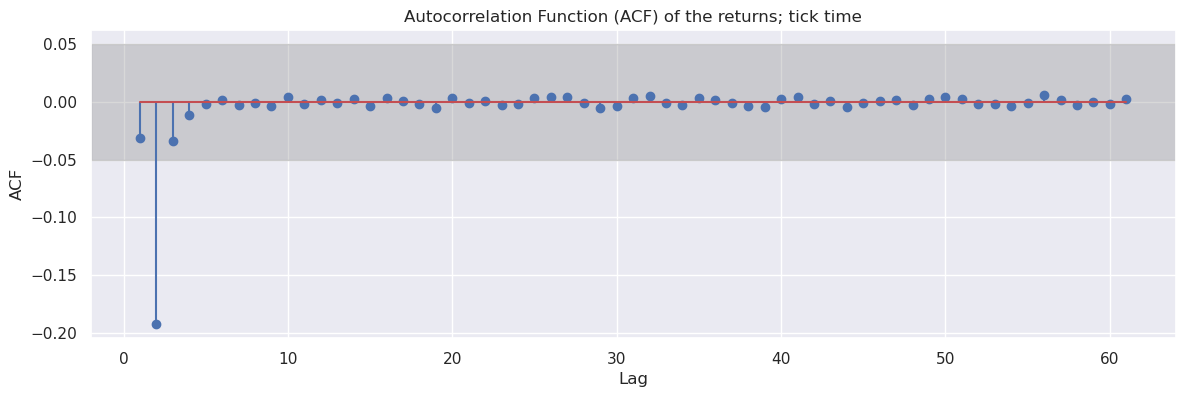

In [21]:

from statsmodels.tsa.stattools import acf

x_train = np.log(df_swap.price.values)
ticks_diff = (df_swap.tick.values - df_swap.tick.shift(1).values)[1:]
x_train = x_train[1:][ ticks_diff!=0 ]
x_train = x_train[1:] - x_train[:-1]

acf_block = acf(x_train)

plt.figure(figsize=(14, 4))
plt.stem(range(1,len(acf_block)), acf_block[1:])
plt.title('Autocorrelation Function (ACF) of the returns; tick time')
plt.axhspan(-0.05, 0.05, alpha=0.3, color='grey')  # Shaded area
plt.xlabel('Lag')
plt.ylabel('ACF')
plt.show()


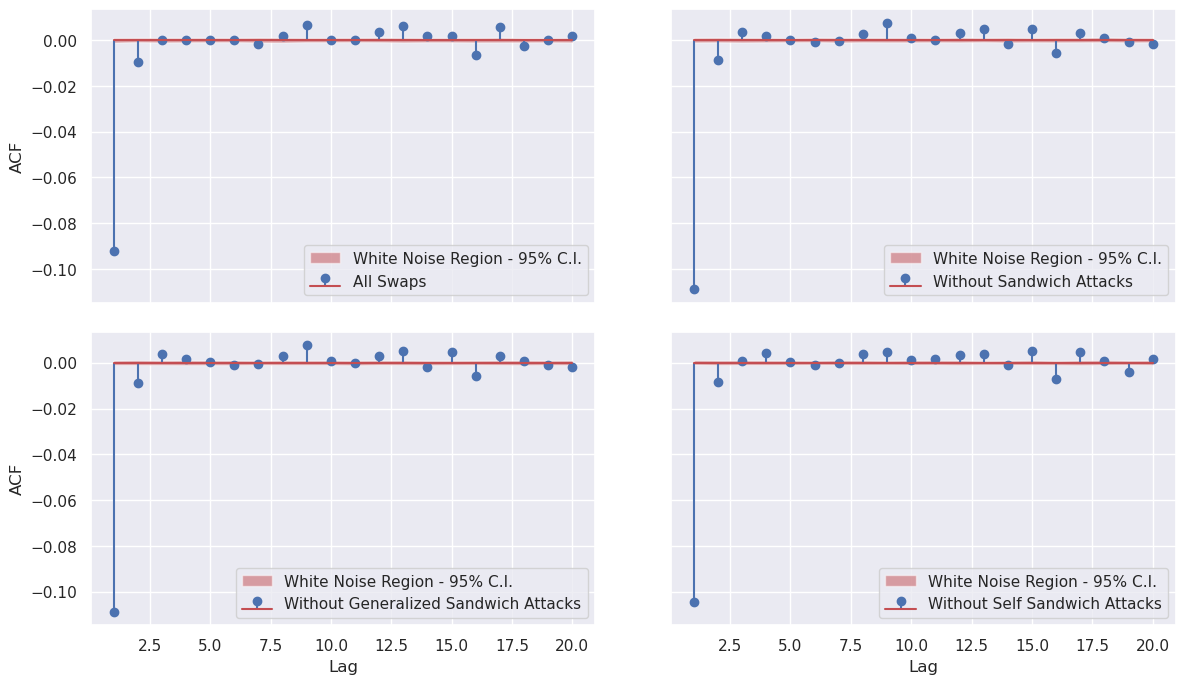

In [ ]:

# Returns ACF - Clean Sandwich Attacks
from statsmodels.tsa.stattools import acf

nlags = 20
selected_labels = [
    ['Not', 'Front', 'Victim', 'Back', 'Front_Gen', 'Victim_Gen', 'Back_Gen', 'Front_Self', 'Victim_Self', 'Back_Self'],
    ['Not', 'Front_Gen', 'Victim_Gen', 'Back_Gen', 'Front_Self', 'Victim_Self', 'Back_Self'],
    ['Not', 'Front_Self', 'Victim_Self', 'Back_Self'],
    ['Not']
]
title_labels = ['All Swaps', 'Without Sandwich Attacks', 'Without Generalized Sandwich Attacks', 'Without Self Sandwich Attacks']

if 'bounds_event_cleaned.pickle' in os.listdir():
    with open('bounds_event_cleaned.pickle', 'rb') as f:
        _, lower_white_noise_bound, upper_white_noise_bound = pickle.load(f)
    bootstrap_flag = False
else:
    bootstrap_array, lower_white_noise_bound,upper_white_noise_bound = dict(), dict(), dict()
    bootstrap_flag = True

with open(pool_name + '_sandwich.pickle', 'rb') as f:
    sandwich_state = pickle.load(f)
    
fig, ax = plt.subplots(2, 2, figsize=(14, 8), sharex=True, sharey=True, gridspec_kw={'wspace':0.15,'hspace':0.1})#, sharey=True)

for n_p, n_min in enumerate(zip(selected_labels, title_labels)):
    curr_list, curr_title = n_min
    n_r, n_c = n_p // 2, n_p % 2

    x_train = np.log(df_swap.loc[[label in curr_list for label in df_swap.sandwich_state]].price.values)
    mask = df_swap.sandwich_state.values[:-1][[label in curr_list for label in df_swap.sandwich_state[1:]]]
    x_train = (x_train[1:] - x_train[:-1])[mask == 'Not']
    acf_block = acf(x_train, nlags=nlags)

    if bootstrap_flag:
        bootstrap_array[curr_title] = utils_DevTrad.bootstrap_iid_autocorr(x_train, 500, nlags)
        lower_white_noise_bound[curr_title] = np.percentile(bootstrap_array[curr_title], 2.5, axis=0)
        upper_white_noise_bound[curr_title] = np.percentile(bootstrap_array[curr_title], 97.5, axis=0)

    utils_DevTrad.plot_acf(
            acf_block, nlags, ax[n_r, n_c], label=curr_title,
            up_bound=upper_white_noise_bound[curr_title],
            low_bound=lower_white_noise_bound[curr_title])
    
    if n_r == 1:
        ax[n_r, n_c].set_xlabel('Lag')
    if n_c == 0:
        ax[n_r, n_c].set_ylabel('ACF')

ax[0, 1].tick_params(axis="y", left=False, labelleft=False)
ax[1, 1].tick_params(axis="y", left=False, labelleft=False)

#plt.savefig(f'stf_acf_{pool_name}_cleaned.pdf', format='pdf', bbox_inches='tight', dpi=300)
plt.show()

if bootstrap_flag:
    with open('bounds_event_cleaned.pickle', 'wb') as f:
        pickle.dump([bootstrap_array, lower_white_noise_bound, upper_white_noise_bound], f)
    del(bootstrap_array)


# Autocorrelation - (Signed) Volume

ACF - Volume Power law - Coef= -0.3185895188705889      Intercept -1.7834277128310543
R2 score: 0.9473636755651131

ACF - Volume Exponential Power law - power= -0.21443682645873516 Coef exp= -0.00023801226975882583      Intercept= -2.265422233866523
R2 score: 0.9696038030990844
The first lag inside the confidence interval is: 0

ACF - Signed Volume Power law - Coef= -0.14554407952665468      Intercept -6.693724731512899
R2 score: 0.013831601978669283

ACF - Signed Volume Exponential Power law - power= -0.3516868605954046 Coef exp= 0.0004558926840127273      Intercept= -5.729470323485178
R2 score: 0.019550217600071917
The first lag inside the confidence interval is: 21


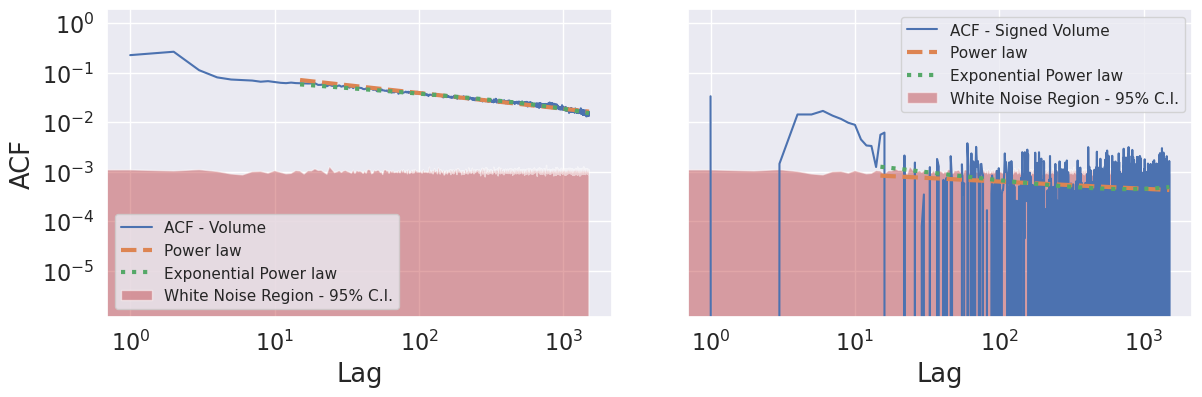

In [2]:

from statsmodels.tsa.stattools import acf

nlags = 1_500

fig, ax = plt.subplots(1, 2, figsize=(14, 4), gridspec_kw={'wspace':0.15})

x_train = np.abs(df_swap.amount0.values)
acf_block = acf(x_train, nlags=nlags)

if 'bounds_vol.pickle' in os.listdir():
    with open('bounds_vol.pickle', 'rb') as f:
        _, lower_white_noise_bound_ev, upper_white_noise_bound_ev = pickle.load(f)
else:
    bootstrap_array_ev = utils_DevTrad.bootstrap_iid_autocorr(x_train, 500, nlags)
    lower_white_noise_bound_ev = np.percentile(bootstrap_array_ev, 2.5, axis=0)
    upper_white_noise_bound_ev = np.percentile(bootstrap_array_ev, 97.5, axis=0)
    with open('bounds_vol.pickle', 'wb') as f:
        pickle.dump([bootstrap_array_ev, lower_white_noise_bound_ev, upper_white_noise_bound_ev], f)
    del(bootstrap_array_ev)

utils_DevTrad.plot_acf_long_memory(
    acf_block, ax[0], start_l=15, label="ACF - Volume",
    up_bound=upper_white_noise_bound_ev,
    low_bound=lower_white_noise_bound_ev, verbose=True)
ax[0].set_xlabel('Lag')
ax[0].set_ylabel('ACF')


x_train = df_swap.amount0.values
acf_block = acf(x_train, nlags=nlags)

if 'bounds_sign_vol.pickle' in os.listdir():
    with open('bounds_sign_vol.pickle', 'rb') as f:
        _, lower_white_noise_bound_ti, upper_white_noise_bound_ti = pickle.load(f)
else:
    bootstrap_array_ti = utils_DevTrad.bootstrap_iid_autocorr(x_train, 500, nlags)
    lower_white_noise_bound_ti = np.percentile(bootstrap_array_ti, 2.5, axis=0)
    upper_white_noise_bound_ti = np.percentile(bootstrap_array_ti, 97.5, axis=0)
    with open('bounds_sign_vol.pickle', 'wb') as f:
        pickle.dump([bootstrap_array_ti, lower_white_noise_bound_ti, upper_white_noise_bound_ti], f)
    del(bootstrap_array_ti)

print()
utils_DevTrad.plot_acf_long_memory(
    acf_block, ax[1], start_l=15, label="ACF - Signed Volume",
    up_bound=upper_white_noise_bound_ev,
    low_bound=lower_white_noise_bound_ev, verbose=True)
ax[1].set_xlabel('Lag')
ax[1].tick_params(axis="y", left=False, labelleft=False)
ax[0].sharey(ax[1])  # Share y-axis for the first row

#plt.savefig(f'stf_acf_vol_{pool_name}.pdf', format='pdf', bbox_inches='tight', dpi=300)
plt.show()


Study the long-memory property after removing sandwich events

ACF - Volume Power law - Coef= -0.3277121311342566      Intercept -1.5271726850063008
R2 score: 0.950638618196935

ACF - Volume Exponential Power law - power= -0.21663285844792735 Coef exp= -0.0002538410597268806      Intercept= -2.041221814180057
R2 score: 0.9746291006377715
The first lag inside the confidence interval is: 0

ACF - Signed Volume Power law - Coef= -0.1270884051178688      Intercept -6.5656216134463605
R2 score: 0.0105780032972691

ACF - Signed Volume Exponential Power law - power= -0.3220254121026472 Coef exp= 0.00043068532499229256      Intercept= -5.65470344005001
R2 score: 0.0157677009952496
The first lag inside the confidence interval is: 22


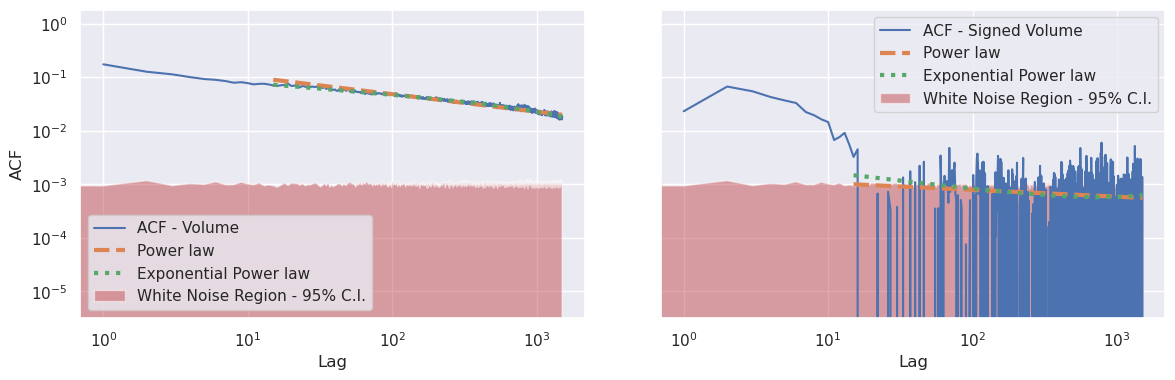

In [3]:

from statsmodels.tsa.stattools import acf

nlags = 1_500

fig, ax = plt.subplots(1, 2, figsize=(14, 4), gridspec_kw={'wspace':0.15})

x_train = np.abs(df_swap.loc[[label=='Not' for label in df_swap.sandwich_state]].amount0.values)
acf_block = acf(x_train, nlags=nlags)

if 'bounds_vol_cleaned.pickle' in os.listdir():
    with open('bounds_vol.pickle', 'rb') as f:
        _, lower_white_noise_bound_ev, upper_white_noise_bound_ev = pickle.load(f)
else:
    bootstrap_array_ev = utils_DevTrad.bootstrap_iid_autocorr(x_train, 500, nlags)
    lower_white_noise_bound_ev = np.percentile(bootstrap_array_ev, 2.5, axis=0)
    upper_white_noise_bound_ev = np.percentile(bootstrap_array_ev, 97.5, axis=0)
    with open('bounds_vol_cleaned.pickle', 'wb') as f:
        pickle.dump([bootstrap_array_ev, lower_white_noise_bound_ev, upper_white_noise_bound_ev], f)
    del(bootstrap_array_ev)

utils_DevTrad.plot_acf_long_memory(
    acf_block, ax[0], start_l=15, label="ACF - Volume",
    up_bound=upper_white_noise_bound_ev,
    low_bound=lower_white_noise_bound_ev, verbose=True)
ax[0].set_xlabel('Lag')
ax[0].set_ylabel('ACF')


x_train = df_swap.loc[[label=='Not' for label in df_swap.sandwich_state]].amount0.values
acf_block = acf(x_train, nlags=nlags)

if 'bounds_sign_vol_cleaned.pickle' in os.listdir():
    with open('bounds_sign_vol_cleaned.pickle', 'rb') as f:
        _, lower_white_noise_bound_ti, upper_white_noise_bound_ti = pickle.load(f)
else:
    bootstrap_array_ti = utils_DevTrad.bootstrap_iid_autocorr(x_train, 500, nlags)
    lower_white_noise_bound_ti = np.percentile(bootstrap_array_ti, 2.5, axis=0)
    upper_white_noise_bound_ti = np.percentile(bootstrap_array_ti, 97.5, axis=0)
    with open('bounds_sign_vol_cleaned.pickle', 'wb') as f:
        pickle.dump([bootstrap_array_ti, lower_white_noise_bound_ti, upper_white_noise_bound_ti], f)
    del(bootstrap_array_ti)

print()
utils_DevTrad.plot_acf_long_memory(
    acf_block, ax[1], start_l=15, label="ACF - Signed Volume",
    up_bound=upper_white_noise_bound_ev,
    low_bound=lower_white_noise_bound_ev, verbose=True)
ax[1].set_xlabel('Lag')
ax[1].tick_params(axis="y", left=False, labelleft=False)
ax[0].sharey(ax[1])  # Share y-axis for the first row

#plt.savefig(f'stf_acf_vol_{pool_name}_clean.pdf', format='pdf', bbox_inches='tight', dpi=300)
plt.show()


# Autocorrelation - Sign(Returns)

ACF Sign - Swap-time Power law - Coef= -0.21775933928911442      Intercept -3.346396087458053
R2 score: 0.9058174106484915

ACF Sign - Swap-time Exponential Power law - power= -0.2593482059968637 Coef exp= 9.503989126527887e-05      Intercept= -3.153932451377071
R2 score: 0.9130748558625167
The first lag inside the confidence interval is: 0
ACF Sign - Tick-time Power law - Coef= -0.1896371408696932      Intercept -3.923367494354415
R2 score: 0.24184888391632975

ACF Sign - Tick-time Exponential Power law - power= -0.30957958005263214 Coef exp= 0.0002740953837031304      Intercept= -3.3683016848484986
R2 score: 0.26310018640764665
The first lag inside the confidence interval is: 0


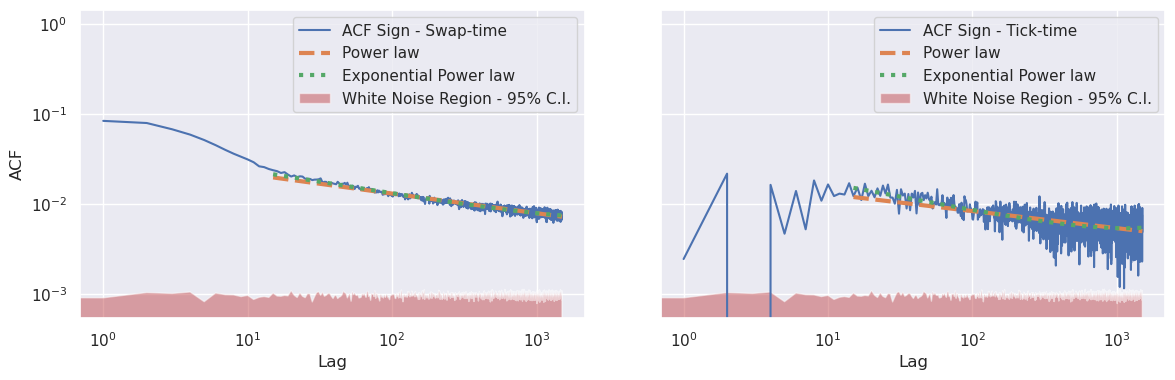

In [4]:

from statsmodels.tsa.stattools import acf

with open(pool_name + '_sandwich.pickle', 'rb') as f:
    sandwich_state = pickle.load(f)

nlags = 1_500

fig, ax = plt.subplots(1, 2, figsize=(14, 4), gridspec_kw={'wspace':0.15})

x_train = np.where(df_swap.Event=='Swap_Y2X', 1., -1.)
acf_block = acf(x_train, nlags=nlags)

if 'bounds_sign_event.pickle' in os.listdir():
    with open('bounds_sign_event.pickle', 'rb') as f:
        _, lower_white_noise_bound_ev, upper_white_noise_bound_ev = pickle.load(f)
else:
    bootstrap_array_ev = utils_DevTrad.bootstrap_iid_autocorr(x_train, 500, nlags)
    lower_white_noise_bound_ev = np.percentile(bootstrap_array_ev, 2.5, axis=0)
    upper_white_noise_bound_ev = np.percentile(bootstrap_array_ev, 97.5, axis=0)
    with open('bounds_sign_event.pickle', 'wb') as f:
        pickle.dump([bootstrap_array_ev, lower_white_noise_bound_ev, upper_white_noise_bound_ev], f)
    del(bootstrap_array_ev)

utils_DevTrad.plot_acf_long_memory(
    acf_block, ax[0], start_l=15, label="ACF Sign - Swap-time",
    up_bound=upper_white_noise_bound_ev,
    low_bound=lower_white_noise_bound_ev, verbose=True)
ax[0].set_xlabel('Lag')
ax[0].set_ylabel('ACF')


x_temp = np.where(df_swap.Event=='Swap_Y2X', 1., -1.)
x_sign = list()
signs, count = 0, 0
for x, t_diff in zip(x_temp, df_swap.tick_time.to_numpy()):
    signs += x
    count += 1
    if t_diff != 0:
        x_sign.append(signs/count)
        signs, count = 0, 0

x_train = np.array(x_sign)
acf_block = acf(x_train, nlags=nlags)

if 'bounds_sign_tick.pickle' in os.listdir():
    with open('bounds_sign_tick.pickle', 'rb') as f:
        _, lower_white_noise_bound_ti, upper_white_noise_bound_ti = pickle.load(f)
else:
    bootstrap_array_ti = utils_DevTrad.bootstrap_iid_autocorr(x_train, 500, nlags)
    lower_white_noise_bound_ti = np.percentile(bootstrap_array_ti, 2.5, axis=0)
    upper_white_noise_bound_ti = np.percentile(bootstrap_array_ti, 97.5, axis=0)
    with open('bounds_sign_tick.pickle', 'wb') as f:
        pickle.dump([bootstrap_array_ti, lower_white_noise_bound_ti, upper_white_noise_bound_ti], f)
    del(bootstrap_array_ti)

utils_DevTrad.plot_acf_long_memory(
    acf_block, ax[1], start_l=15, label="ACF Sign - Tick-time",
    up_bound=upper_white_noise_bound_ev,
    low_bound=lower_white_noise_bound_ev, verbose=True)
ax[1].set_xlabel('Lag')
ax[1].tick_params(axis="y", left=False, labelleft=False)
ax[0].sharey(ax[1])  # Share y-axis for the first row

#plt.savefig(f'stf_acf_sign_ev_tick_{pool_name}.pdf', format='pdf', bbox_inches='tight', dpi=300)
plt.show()


Study the long-memory property after removing sandwich events

ACF - Sign Power law - Coef= -0.21852734412226762      Intercept -3.338809839661212
R2 score: 0.9100751639432734

ACF - Sign Exponential Power law - power= -0.26145614852076954 Coef exp= 9.81019495157786e-05      Intercept= -3.1401452825044904
R2 score: 0.9177896284303905
The first lag inside the confidence interval is: 0


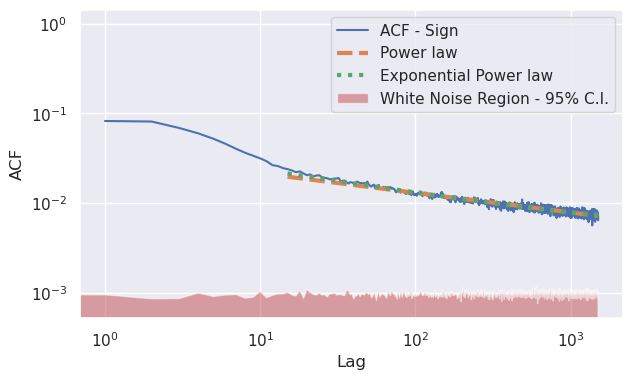

In [5]:

from statsmodels.tsa.stattools import acf

nlags = 1_500

fig, ax = plt.subplots(1, 1, figsize=(7, 4), gridspec_kw={'wspace':0.15})

x_train = df_swap.loc[[label=='Not' for label in df_swap.sandwich_state]].Event.values
x_train = np.where(x_train=='Swap_Y2X', 1., -1.)
acf_block = acf(x_train, nlags=nlags)

if 'bounds_sign_event_clean.pickle' in os.listdir():
    with open('bounds_sign_event_clean.pickle', 'rb') as f:
        _, lower_white_noise_bound_ev, upper_white_noise_bound_ev = pickle.load(f)
else:
    bootstrap_array_ev = utils_DevTrad.bootstrap_iid_autocorr(x_train, 500, nlags)
    lower_white_noise_bound_ev = np.percentile(bootstrap_array_ev, 2.5, axis=0)
    upper_white_noise_bound_ev = np.percentile(bootstrap_array_ev, 97.5, axis=0)
    with open('bounds_sign_event_clean.pickle', 'wb') as f:
        pickle.dump([bootstrap_array_ev, lower_white_noise_bound_ev, upper_white_noise_bound_ev], f)
    del(bootstrap_array_ev)

utils_DevTrad.plot_acf_long_memory(
    acf_block, ax, start_l=15, label="ACF - Sign",
    up_bound=upper_white_noise_bound_ev,
    low_bound=lower_white_noise_bound_ev, verbose=True)
ax.set_xlabel('Lag')
ax.set_ylabel('ACF')

#plt.savefig(f'stf_acf_sign_ev_tick_{pool_name}_cleaned.pdf', format='pdf', bbox_inches='tight', dpi=300)
plt.show()


# Autocorrelation - |Returns|

Study the long-memory property after removing sandwich events

ACF - Abs(Ret) Power law - Coef= -0.24112893831283028      Intercept -0.928898518904733
R2 score: 0.8746663073296864

ACF - Abs(Ret) Exponential Power law - power= -0.06561636980260988 Coef exp= -0.0004010855968766549      Intercept= -1.7411300074606684
R2 score: 0.9764557376333206
The first lag inside the confidence interval is: 0


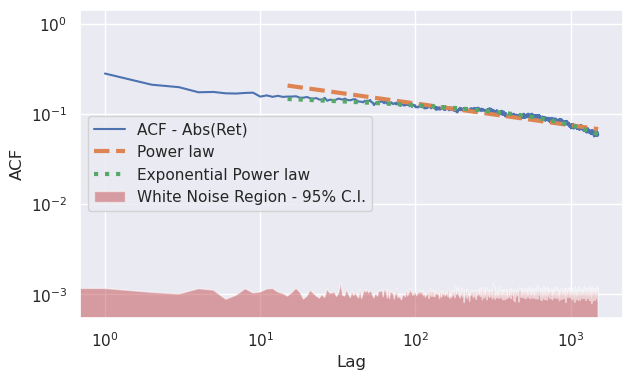

In [ ]:

from statsmodels.tsa.stattools import acf

nlags = 1_500

fig, ax = plt.subplots(1, 1, figsize=(7, 4), gridspec_kw={'wspace':0.15})

x_train = np.log(df_swap.loc[[label == 'Not' for label in df_swap.sandwich_state]].price.values)
mask = df_swap.sandwich_state.values[:-1][[label == 'Not' for label in df_swap.sandwich_state[1:]]]
x_train = np.abs(x_train[1:] - x_train[:-1])[mask == 'Not']
acf_block = acf(x_train, nlags=nlags)

if 'bounds_absret_cleaned.pickle' in os.listdir():
    with open('bounds_absret_cleaned.pickle', 'rb') as f:
        _, lower_white_noise_bound_ev, upper_white_noise_bound_ev = pickle.load(f)
else:
    bootstrap_array_ev = utils_DevTrad.bootstrap_iid_autocorr(x_train, 500, nlags)
    lower_white_noise_bound_ev = np.percentile(bootstrap_array_ev, 2.5, axis=0)
    upper_white_noise_bound_ev = np.percentile(bootstrap_array_ev, 97.5, axis=0)
    with open('bounds_absret_cleaned.pickle', 'wb') as f:
        pickle.dump([bootstrap_array_ev, lower_white_noise_bound_ev, upper_white_noise_bound_ev], f)
    del(bootstrap_array_ev)

utils_DevTrad.plot_acf_long_memory(
    acf_block, ax, start_l=15, label="ACF - Abs(Ret)",
    up_bound=upper_white_noise_bound_ev,
    low_bound=lower_white_noise_bound_ev, verbose=True)
ax.set_xlabel('Lag')
ax.set_ylabel('ACF')
ax.legend()

#plt.savefig(f'stf_acf_sign_ev_tick_{pool_name}_clean.pdf', format='pdf', bbox_inches='tight', dpi=300)
plt.show()


KeyboardInterrupt: 

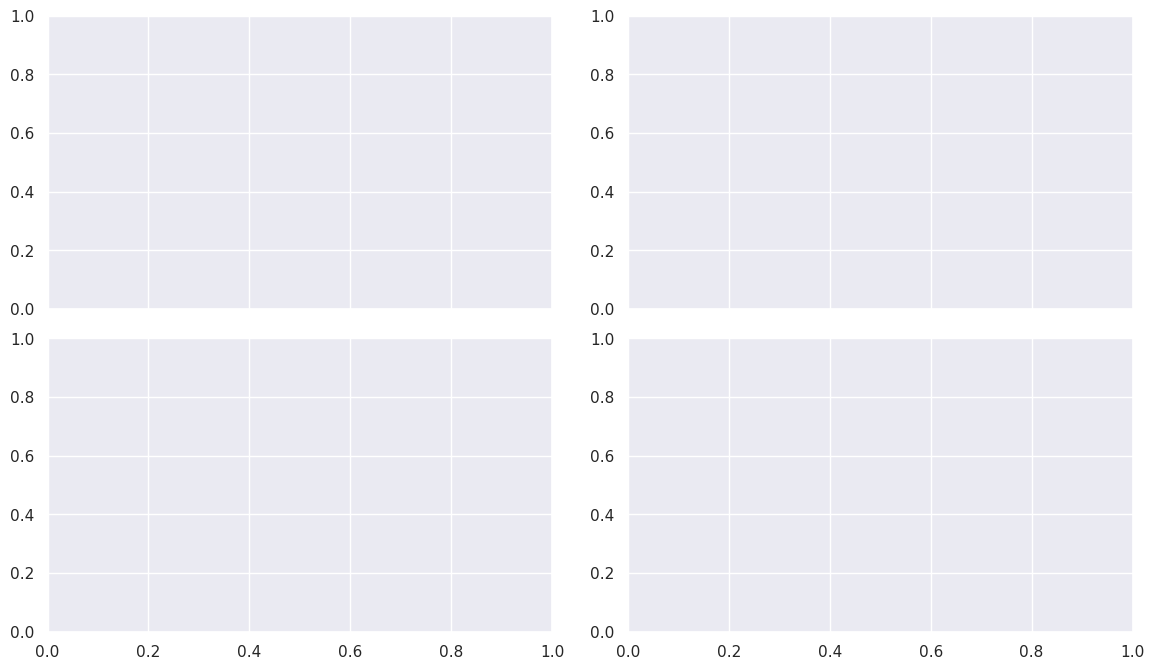

In [29]:

from sklearn.linear_model import QuantileRegressor
from sklearn.utils.fixes import parse_version, sp_version
solver = "highs" if sp_version >= parse_version("1.6.0") else "interior-point"

if 'vol_vol_models.pickle' in os.listdir():
    with open('vol_vol_models.pickle', 'rb') as f:
        qr_models = pickle.load(f)
else:
    qr_models = dict()

fig, ax = plt.subplots(2, 2, figsize=(14,8), sharex=True, gridspec_kw={'wspace':0.15,'hspace':0.1})

for n_p, n_min in enumerate([1, 5, 10, 30]):
    n_r, n_c = n_p // 2, n_p % 2

    df_swap['amount'] = np.abs(df_swap['amount0'])
    volume = df_swap['amount'].resample(f'{n_min}min').sum()
    volume = volume.fillna(value=0).values
    squared_diff = (np.log(df_swap.price).diff())**2
    real_vol = squared_diff.resample(f'{n_min}min').sum()
    real_vol = real_vol.fillna(value=0).values
    volume, real_vol = volume[~ ((volume==0) | (real_vol==0))], real_vol[~ ((volume==0) | (real_vol==0))]

    X = np.log(real_vol).reshape(-1, 1)
    y = np.log(volume)

    if n_min in qr_models.keys():
        mdl, qr_05, qr95 = qr_models[n_min]
        fitted_vals_m = mdl.predict(np.log(real_vol).reshape(-1, 1))
        fitted_vals_05 = qr_05.fit(X, y).predict(X)
        fitted_vals_95 = qr95.fit(X, y).predict(X)
    else:
        #------------------------------ Regress the mean
        from sklearn.linear_model import LinearRegression
        mdl = LinearRegression(fit_intercept=True)
        mdl.fit(np.log(real_vol).reshape(-1, 1), np.log(volume))
        fitted_vals_m = mdl.predict(np.log(real_vol).reshape(-1, 1))

        #------------------------------ Quantile regression
        qr_05 = QuantileRegressor(quantile=0.05, alpha=0, solver=solver, fit_intercept=True)
        fitted_vals_05 = qr_05.fit(X, y).predict(X)
        qr95 = QuantileRegressor(quantile=0.95, alpha=0, solver=solver, fit_intercept=True)
        fitted_vals_95 = qr95.fit(X, y).predict(X)
        
        qr_models[n_min] = [mdl, qr_05, qr95]
        with open('vol_vol_models.pickle', 'wb') as f:
            pickle.dump(qr_models, f)

    sns.scatterplot(x=np.log(real_vol), y=np.log(volume), label=f'Empirical Data - {n_min} Minutes', ax=ax[n_r, n_c])

    sns.lineplot(x=np.log(real_vol), y=fitted_vals_m, linewidth=3,
                color=sns.color_palette()[1], label=f'Fitted Mean', ax=ax[n_r, n_c])
    sns.lineplot(x=np.log(real_vol), y=fitted_vals_05, linestyle='--', linewidth=3,
                color=sns.color_palette()[1], label=f'Fitted 0.05 Quantile', ax=ax[n_r, n_c])
    sns.lineplot(x=np.log(real_vol), y=fitted_vals_95, linestyle='--', linewidth=3,
                color=sns.color_palette()[1], label=f'Fitted 0.95 Quantile', ax=ax[n_r, n_c])
    
    print(
        'Minute', n_min,
        rf'; mean: Fitted $Vol = e^{{{mdl.intercept_:.2f}}} \cdot RV^{{{mdl.coef_[0]:.2f}}}$; R2 score =',
        mdl.score(np.log(real_vol).reshape(-1, 1), np.log(volume)))
    print('Minute', n_min, rf'; lower quantile: Fitted $Vol = e^{{{qr_05.intercept_:.2f}}} \cdot RV^{{{qr_05.coef_[0]:.2f}}}$')
    print('Minute', n_min, rf'; upper quantile: Fitted $Vol = e^{{{qr95.intercept_:.2f}}} \cdot RV^{{{qr95.coef_[0]:.2f}}}$')
    print()

    ax[n_r, n_c].legend(loc='lower right')
    
ax[0, 1].sharey(ax[0, 0])  # Share y-axis for the first row
ax[1, 1].sharey(ax[1, 0])  # Share y-axis for the second row

ax[0, 1].tick_params(axis="y", left=False, labelleft=False)
ax[1, 1].tick_params(axis="y", left=False, labelleft=False)

ax[1, 0].set_xlabel('Log Realized Variance')
ax[1, 1].set_xlabel('Log Realized Variance')
ax[0, 0].set_ylabel('Log Volume')
ax[1, 0].set_ylabel('Log Volume')

#plt.savefig(f'stf_vol_vs_rv_min_{pool_name}.pdf', format='pdf', bbox_inches='tight', dpi=300)
plt.show()


# Liquidity

Study the number and diversification of JIT LPs

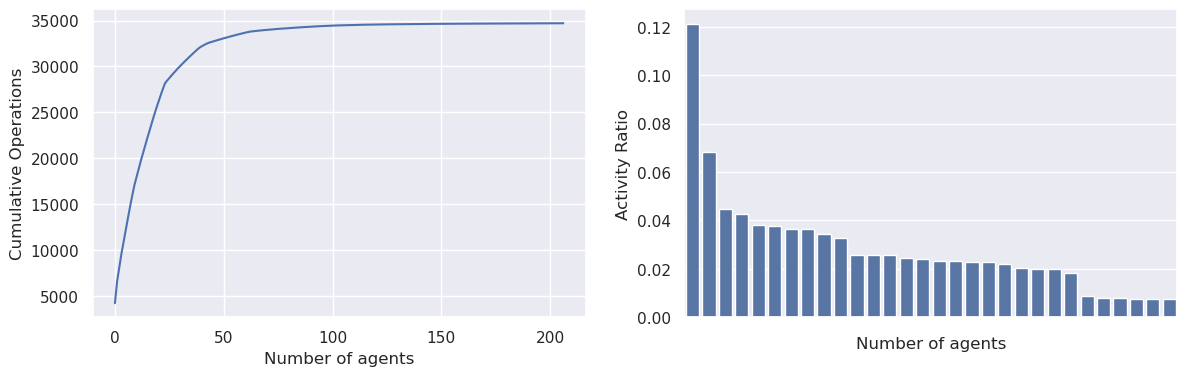

In [12]:

_, mint_count = np.unique(df_mint[ df_mint.JIT_flag==1 ].wallet, return_counts=True)
mint_idx = np.argsort(mint_count)[::-1]
mint_count = mint_count[mint_idx]
mint_ratio = mint_count / mint_count.sum()

fig, ax = plt.subplots(1, 2, figsize=(14,4))

sub_p = 0
sns.lineplot(x=range(len(mint_count)), y=np.cumsum(mint_count), ax=ax[sub_p])
ax[sub_p].set_xlabel('Number of agents')
ax[sub_p].set_ylabel('Cumulative Operations')

sub_p = 1

to_plot = 30
df = pd.DataFrame({
    'Index': range(to_plot),
    'Value': mint_ratio[:to_plot]
})
# Create a bar plot
sns.barplot(data=df, x='Index', y='Value', color=sns.color_palette()[0], ax=ax[sub_p])

ax[sub_p].set_xlabel('Number of agents')
ax[sub_p].set_ylabel('Activity Ratio')
ax[sub_p].set_xticklabels([])

#plt.savefig(f'jit_agents_impact_{pool_name}.pdf', format='pdf', bbox_inches='tight', dpi=300)
plt.show()


Study the number and diversification of non-JIT LPs

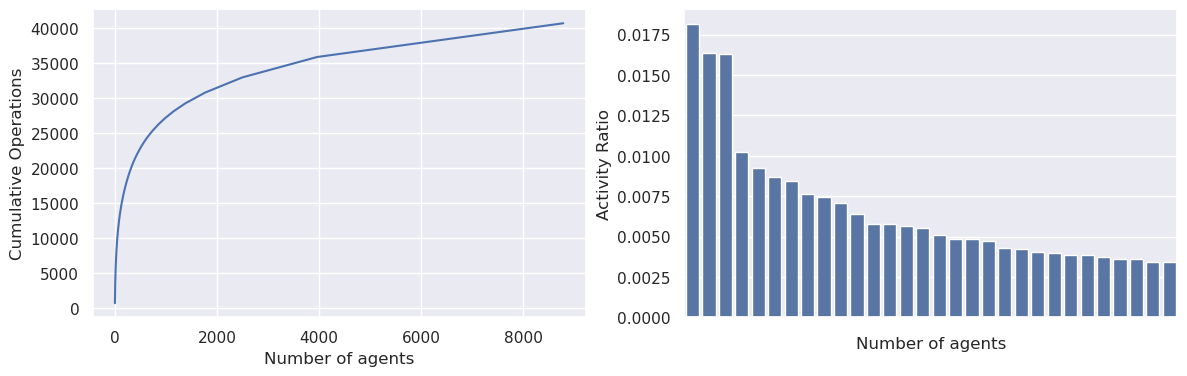

In [14]:

_, mint_count = np.unique(df_mint[ df_mint.JIT_flag==0 ].wallet, return_counts=True)
mint_idx = np.argsort(mint_count)[::-1]
mint_count = mint_count[mint_idx]
mint_ratio = mint_count / mint_count.sum()

fig, ax = plt.subplots(1, 2, figsize=(14,4))

sub_p = 0
sns.lineplot(x=range(len(mint_count)), y=np.cumsum(mint_count), ax=ax[sub_p])
ax[sub_p].set_xlabel('Number of agents')
ax[sub_p].set_ylabel('Cumulative Operations')

sub_p = 1

to_plot = 30
df = pd.DataFrame({
    'Index': range(to_plot),
    'Value': mint_ratio[:to_plot]
})
# Create a bar plot
sns.barplot(data=df, x='Index', y='Value', color=sns.color_palette()[0], ax=ax[sub_p])

ax[sub_p].set_xlabel('Number of agents')
ax[sub_p].set_ylabel('Activity Ratio')
ax[sub_p].set_xticklabels([])

#plt.savefig(f'non_jit_agents_impact_{pool_name}.pdf', format='pdf', bbox_inches='tight', dpi=300)
plt.show()


ACF Liquidity - JIT Power law - Coef= -0.07407560870262493      Intercept -0.5618285293383616
R2 score: 0.9209381591777224

ACF Liquidity - JIT Exponential Power law - power= -0.04525561588132965 Coef exp= -7.552013465966101e-05      Intercept= -0.6871855470998631
R2 score: 0.965056390629
The first lag inside the confidence interval is: 0
Negative ACF Liquidity - non-JIT Power law - Coef= 0.009085745367407548      Intercept -10.652019161189434
R2 score: 0.7026200101839326

Negative ACF Liquidity - non-JIT Exponential Power law - power= -0.00014595336790464226 Coef exp= 2.4190815589414307e-05      Intercept= -10.611864459225863
R2 score: 0.9321888745035556
The first lag inside the confidence interval is: 0


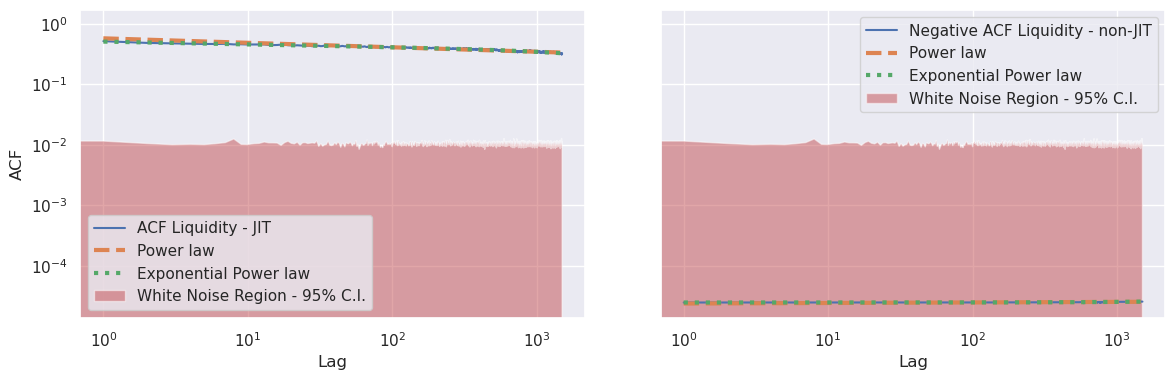

In [23]:

from statsmodels.tsa.stattools import acf
from sklearn.linear_model import LinearRegression

nlags = 1_500

fig, ax = plt.subplots(1, 2, figsize=(14, 4), gridspec_kw={'wspace':0.15})

#------------------------------------ ACF of Liquidity minted in JIT attacks
x_train = df_mint[ df_mint.JIT_flag==1 ].amount.to_numpy().astype(np.float64)
acf_block = acf(x_train, nlags=nlags)

if 'bounds_liq_jit.pickle' in os.listdir():
    with open('bounds_liq_jit.pickle', 'rb') as f:
        _, lower_white_noise_bound_ev, upper_white_noise_bound_ev = pickle.load(f)
else:
    bootstrap_array_ev = utils_DevTrad.bootstrap_iid_autocorr(x_train, 500, nlags)
    lower_white_noise_bound_ev = np.percentile(bootstrap_array_ev, 2.5, axis=0)
    upper_white_noise_bound_ev = np.percentile(bootstrap_array_ev, 97.5, axis=0)
    with open('bounds_liq_jit.pickle', 'wb') as f:
        pickle.dump([bootstrap_array_ev, lower_white_noise_bound_ev, upper_white_noise_bound_ev], f)
    del(bootstrap_array_ev)

utils_DevTrad.plot_acf_long_memory(
    acf_block, ax[0], start_l=1, label="ACF Liquidity - JIT",
    up_bound=lower_white_noise_bound_ev,
    low_bound=upper_white_noise_bound_ev, verbose=True)
ax[0].set_xlabel('Lag')
ax[0].set_ylabel('ACF')


#------------------------------------ ACF of Liquidity minted in non-JIT mints
x_train = df_mint[ df_mint.JIT_flag==0 ].amount.to_numpy().astype(np.float64)
acf_block = acf(x_train, nlags=nlags)

if 'bounds_liq_noj.pickle' in os.listdir():
    with open('bounds_liq_noj.pickle', 'rb') as f:
        _, lower_white_noise_bound_ti, upper_white_noise_bound_ti = pickle.load(f)
else:
    bootstrap_array_ti = utils_DevTrad.bootstrap_iid_autocorr(x_train, 500, nlags)
    lower_white_noise_bound_ti = np.percentile(bootstrap_array_ti, 2.5, axis=0)
    upper_white_noise_bound_ti = np.percentile(bootstrap_array_ti, 97.5, axis=0)
    with open('bounds_liq_noj.pickle', 'wb') as f:
        pickle.dump([bootstrap_array_ti, lower_white_noise_bound_ti, upper_white_noise_bound_ti], f)
    del(bootstrap_array_ti)

utils_DevTrad.plot_acf_long_memory(
    -acf_block, ax[1], start_l=1, label="Negative ACF Liquidity - non-JIT",
    up_bound=lower_white_noise_bound_ev,
    low_bound=upper_white_noise_bound_ev, verbose=True)
ax[1].set_xlabel('Lag')
ax[1].tick_params(axis="y", left=False, labelleft=False)

ax[0].sharey(ax[1])  # Share y-axis for the first row
#plt.savefig(f'stf_acf_sign_ev_tick_{pool_name}.pdf', format='pdf', bbox_inches='tight', dpi=300)
plt.show()


ACF Tick Range Power law - Coef= -0.6635462906719732      Intercept -0.45919567829672125
R2 score: 0.3430512830083544

ACF Tick Range Exponential Power law - power= 0.07936059808782667 Coef exp= -0.001755301001597595      Intercept= -3.8774456671408792
R2 score: 0.4419314964830978
The first lag inside the confidence interval is: 27


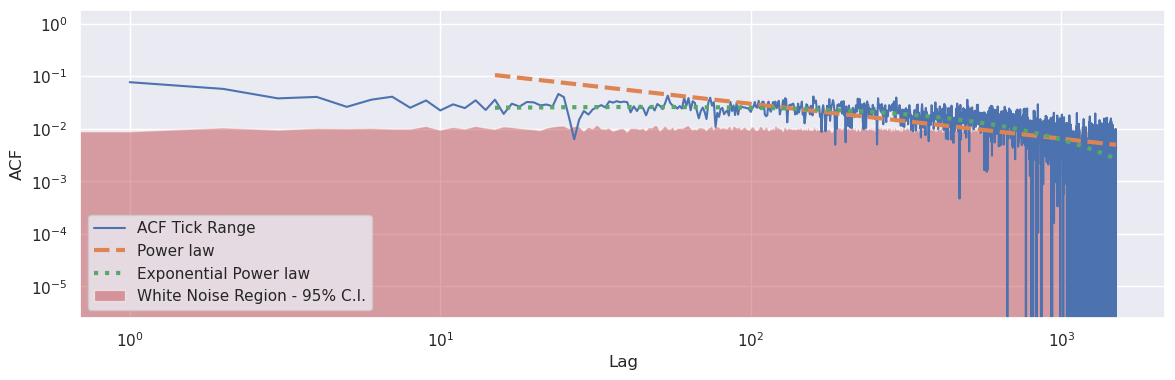

In [13]:

from statsmodels.tsa.stattools import acf

nlags = 1_500

x_train = df_mint[ df_mint.JIT_flag==0 ].tick_upper.to_numpy() -\
    df_mint[ df_mint.JIT_flag==0 ].tick_lower.to_numpy()

acf_block = acf(x_train, nlags=nlags)

if 'bounds_liq_tr.pickle' in os.listdir():
    with open('bounds_liq_tr.pickle', 'rb') as f:
        _, lower_white_noise_bound_tr, upper_white_noise_bound_tr = pickle.load(f)
else:
    bootstrap_array_tr = utils_DevTrad.bootstrap_iid_autocorr(x_train, 500, nlags)
    lower_white_noise_bound_tr = np.percentile(bootstrap_array_tr, 2.5, axis=0)
    upper_white_noise_bound_tr = np.percentile(bootstrap_array_tr, 97.5, axis=0)
    with open('bounds_liq_tr.pickle', 'wb') as f:
        pickle.dump([bootstrap_array_tr, lower_white_noise_bound_tr, upper_white_noise_bound_tr], f)
    del(bootstrap_array_tr)

fig, ax = plt.subplots(figsize=(14, 4))

utils_DevTrad.plot_acf_long_memory(
    acf_block, ax, start_l=15, label="ACF Tick Range",
    up_bound=upper_white_noise_bound_tr,
    low_bound=lower_white_noise_bound_tr, verbose=True)

plt.xlabel('Lag')
plt.ylabel('ACF')
#plt.savefig(f'../figures/stf_acf_tick_range_{pool_name}.pdf', format='pdf', bbox_inches='tight', dpi=300)
plt.show()
